# Import Libraries

In [1]:
#import libraries
import os
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_palette("pastel")

# **Food Price in 2022**

## Price Dataset

In [2]:
folder_path = "Dataset/Price_Data" 
extension = 'csv'

# Get full path to files
all_filenames = glob.glob(os.path.join(folder_path, f"*.{extension}"))

# Combine files
df_price = pd.concat([pd.read_csv(f) for f in all_filenames])

In [4]:
#print total number of lines in df_price
print("Total Lines: ", len(df_price))

Total Lines:  27403983


In [6]:
#show data types of attributes in df_price
df_price.dtypes

date             object
premise_code      int64
item_code         int64
price           float64
dtype: object

In [7]:
#convert date from object data type to string data type
df_price['date'] = df_price['date'].astype('str')

In [8]:
#show number of values for each attribute in df_price
for column in df_price:
  unique_vals = np.unique(df_price[column])
  nr_values = len(unique_vals)
  if nr_values < 36:
    print('The number of values for feature {} :{} -- {}'.format(column, nr_values, unique_vals))
  else:
    print('The number of values for feature {} :{}'.format(column, nr_values))

The number of values for feature date :355
The number of values for feature premise_code :2671
The number of values for feature item_code :757
The number of values for feature price :4193


## **Premise Dataset**


In [9]:
#import dataset
df_premise = pd.read_csv("Dataset/lookup_premise.csv")

In [10]:
#show top 5 lines of df_premise
df_premise.head()

,premise_code,premise,address,premise_type,state,district
0,-1.0,NaN,",",NaN,NaN,NaN
1,2.0,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
2,3.0,JUSCO AYER KEROH,"LOT 4991,MUKIM BUKIT BARU,75450 LEBUH AYER KER...",Pasar Raya / Supermarket,Melaka,Melaka Tengah
3,6.0,KEDAI RUNCIT TAFAZ MAJU PRESINT 9,"NO.5, JALAN P9B/1,PRESINT 9,62250 PUTRAJAYA",Kedai Runcit,W.P. Putrajaya,Wp Putrajaya
4,7.0,KEDAI RUNCIT SYAZ MAJU PRESINT 9,"NO.5, JALAN P9E/1,PRESINT 9,62250 PUTRAJAYA",Kedai Runcit,W.P. Putrajaya,Wp Putrajaya


In [11]:
#show data types of attributes in df_premise
df_premise.dtypes

premise_code    float64
premise          object
address          object
premise_type     object
state            object
district         object
dtype: object

In [12]:
#print total number of lines in df_premise
print("Total Lines: ", len(df_premise))

Total Lines:  2996


In [13]:
#convert attributes with object data type from object data type to string data type
df_premise['premise_code'] = df_premise['premise_code'].astype('Int64')
df_premise['premise']      = df_premise['premise'].astype('str')
df_premise['address']      = df_premise['address'].astype('str')
df_premise['premise_type'] = df_premise['premise_type'].astype('str')
df_premise['state']        = df_premise['state'].astype('str')
df_premise['district']     = df_premise['district'].astype('str')

In [14]:
#show number of values for each attribute in df_premise
for column in df_premise:
  unique_vals = np.unique(df_premise[column])
  nr_values = len(unique_vals)
  if nr_values < 36:
    print('The number of values for feature {} :{} -- {}'.format(column, nr_values, unique_vals))
  else:
    print('The number of values for feature {} :{}'.format(column, nr_values))

The number of values for feature premise_code :2996
The number of values for feature premise :2984
The number of values for feature address :2983
The number of values for feature premise_type :14 -- ['Borong' 'Foodcourt' 'Hypermarket' 'Kedai Runcit' 'Kedai Serbaneka'
 'Medan Selera' 'Pasar Basah' 'Pasar Basah ' 'Pasar Mini'
 'Pasar Raya / Supermarket' 'Restoran Cina' 'Restoran India Muslim'
 'Restoran Melayu' 'nan']
The number of values for feature state :17 -- ['Johor' 'Kedah' 'Kelantan' 'Melaka' 'Negeri Sembilan' 'Pahang' 'Perak'
 'Perlis' 'Pulau Pinang' 'Sabah' 'Sarawak' 'Selangor' 'Terengganu'
 'W.P. Kuala Lumpur' 'W.P. Labuan' 'W.P. Putrajaya' 'nan']
The number of values for feature district :175


In [15]:
#drop first row that indicates nothing in df_premise
df_premise = df_premise. drop([0])

In [16]:
#show top 5 lines of df_premise after dropping first row
df_premise.head()

,premise_code,premise,address,premise_type,state,district
1,2,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
2,3,JUSCO AYER KEROH,"LOT 4991,MUKIM BUKIT BARU,75450 LEBUH AYER KER...",Pasar Raya / Supermarket,Melaka,Melaka Tengah
3,6,KEDAI RUNCIT TAFAZ MAJU PRESINT 9,"NO.5, JALAN P9B/1,PRESINT 9,62250 PUTRAJAYA",Kedai Runcit,W.P. Putrajaya,Wp Putrajaya
4,7,KEDAI RUNCIT SYAZ MAJU PRESINT 9,"NO.5, JALAN P9E/1,PRESINT 9,62250 PUTRAJAYA",Kedai Runcit,W.P. Putrajaya,Wp Putrajaya
5,8,PASAR MINI D'MART PRESINT 8,"BLOK A T00/U01,JALAN P8/D,PRESINT 8, 62000 PUT...",Pasar Mini,W.P. Putrajaya,Wp Putrajaya


## **Item Dataset**

In [17]:
#import dataset
df_item = pd.read_csv("Dataset/lookup_item.csv")

#show top 5 lines of df_item
df_item.head()

,item_code,item,unit,item_group,item_category
0,-1,NaN,NaN,NaN,NaN
1,1,AYAM BERSIH - STANDARD,1kg,BARANGAN SEGAR,AYAM
2,2,AYAM BERSIH - SUPER,1kg,BARANGAN SEGAR,AYAM
3,3,AYAM HIDUP,1kg,BARANGAN SEGAR,AYAM
4,9,DAGING KAMBING BEBIRI IMPORT BERTULANG (MUTTON...,1kg,BARANGAN SEGAR,DAGING


In [18]:
#drop first row that indicates nothing in df_item
df_item = df_item.drop([0])

#show top 5 lines of df_item after removing the first row
df_item.head()

,item_code,item,unit,item_group,item_category
1,1,AYAM BERSIH - STANDARD,1kg,BARANGAN SEGAR,AYAM
2,2,AYAM BERSIH - SUPER,1kg,BARANGAN SEGAR,AYAM
3,3,AYAM HIDUP,1kg,BARANGAN SEGAR,AYAM
4,9,DAGING KAMBING BEBIRI IMPORT BERTULANG (MUTTON...,1kg,BARANGAN SEGAR,DAGING
5,10,DAGING KAMBING BEBIRI IMPORT BERTULANG (MUTTON...,1kg,BARANGAN SEGAR,DAGING


In [19]:
#show data types of attributes in df_item
df_item.dtypes

item_code         int64
item             object
unit             object
item_group       object
item_category    object
dtype: object

In [20]:
#print total number of lines in df_item
print("Total Lines: ", len(df_item))

Total Lines:  756


In [21]:
#convert attributes with object data type from object data type to string data type
df_item['item']          = df_item['item'].astype('str')
df_item['unit']          = df_item['unit'].astype('str')
df_item['item_group']    = df_item['item_group'].astype('str')
df_item['item_category'] = df_item['item_category'].astype('str')

In [22]:
#show number of values for each attribute in df_item
for column in df_item:
  unique_vals = np.unique(df_item[column])
  nr_values = len(unique_vals)
  if nr_values < 36:
    print('The number of values for feature {} :{} -- {}'.format(column, nr_values, unique_vals))
  else:
    print('The number of values for feature {} :{}'.format(column, nr_values))

The number of values for feature item_code :756
The number of values for feature item :710
The number of values for feature unit :141
The number of values for feature item_group :8 -- ['BARANGAN BERBUNGKUS' 'BARANGAN KEDAI SERBANEKA' 'BARANGAN KERING'
 'BARANGAN SEGAR' 'MAKANAN SIAP MASAK' 'MINUMAN' 'PRODUK KEBERSIHAN'
 'SUSU DAN BARANGAN BAYI']
The number of values for feature item_category :59


## **Dataframes Merging**

In [23]:
#show list of attributes for each dataset
print("Price dataset columns:", df_price.columns)
print("Premise dataset columns:", df_premise.columns)
print("Item dataset columns:", df_item.columns)

Price dataset columns: Index(['date', 'premise_code', 'item_code', 'price'], dtype='object')
Premise dataset columns: Index(['premise_code', 'premise', 'address', 'premise_type', 'state',
       'district'],
      dtype='object')
Item dataset columns: Index(['item_code', 'item', 'unit', 'item_group', 'item_category'], dtype='object')


In [24]:
#merge df_price and df_premise based on the premise code
df_price_premise = pd.merge(df_price, df_premise, how = 'left', left_on = 'premise_code', right_on = 'premise_code')

In [25]:
#merge df_price_premise and df_item based on the item code
df_price_premise_item = pd.merge(df_price_premise, df_item, how = 'left', left_on = 'item_code', right_on = 'item_code')

In [26]:
#show top 5 lines of merged dataframe
df_price_premise_item.head()

,date,premise_code,item_code,price,premise,address,premise_type,state,district,item,unit,item_group,item_category
0,2022-01-01,2,1,9.1,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta,AYAM BERSIH - STANDARD,1kg,BARANGAN SEGAR,AYAM
1,2022-01-01,2,9,36.0,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta,DAGING KAMBING BEBIRI IMPORT BERTULANG (MUTTON...,1kg,BARANGAN SEGAR,DAGING
2,2022-01-01,2,14,24.0,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta,DAGING KERBAU IMPORT (INDIA) * (TOP SIDE),1kg,BARANGAN SEGAR,DAGING
3,2022-01-01,2,16,4.3,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta,BETIK BIASA,1kg,BARANGAN SEGAR,BUAH-BUAHAN
4,2022-01-01,2,18,4.5,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta,PISANG BERANGAN,1kg,BARANGAN SEGAR,BUAH-BUAHAN


In [27]:
#print total number of lines in df_price_premise_item
print("Total Lines: ", len(df_price_premise_item))

Total Lines:  27403983


## **Data Cleaning**

In [28]:
#keep rows with state='Pulau Pinang' in df_PP
df_price_PP = df_price_premise_item[df_price_premise_item["state"] == 'Pulau Pinang']

In [29]:
df_price_PP.dtypes

date              object
premise_code       int64
item_code          int64
price            float64
premise           object
address           object
premise_type      object
state             object
district          object
item              object
unit              object
item_group        object
item_category     object
dtype: object

In [30]:
# Drop the 'state' column
df_price_PP = df_price_PP.drop(columns=['state'])

In [31]:
#print total number of lines in df_PP
print("Total Lines: ", len(df_price_PP))

Total Lines:  2099460


In [32]:
#show top 5 lines of df_PP
df_price_PP.head()

,date,premise_code,item_code,price,premise,address,premise_type,district,item,unit,item_group,item_category
29393,2022-01-01,1959,16,5.0,PASAR BESAR SUNGAI ARA,"TINGKAT SUNGAI ARA 1,SUNGAI ARA,11900 BAYAN LE...",Pasar Basah,Barat Daya,BETIK BIASA,1kg,BARANGAN SEGAR,BUAH-BUAHAN
29394,2022-01-01,1959,18,6.0,PASAR BESAR SUNGAI ARA,"TINGKAT SUNGAI ARA 1,SUNGAI ARA,11900 BAYAN LE...",Pasar Basah,Barat Daya,PISANG BERANGAN,1kg,BARANGAN SEGAR,BUAH-BUAHAN
29395,2022-01-01,1959,19,6.0,PASAR BESAR SUNGAI ARA,"TINGKAT SUNGAI ARA 1,SUNGAI ARA,11900 BAYAN LE...",Pasar Basah,Barat Daya,PISANG EMAS,1kg,BARANGAN SEGAR,BUAH-BUAHAN
29396,2022-01-01,1959,21,4.0,PASAR BESAR SUNGAI ARA,"TINGKAT SUNGAI ARA 1,SUNGAI ARA,11900 BAYAN LE...",Pasar Basah,Barat Daya,TEMBIKAI MERAH TANPA BIJI,1kg,BARANGAN SEGAR,BUAH-BUAHAN
29397,2022-01-01,1959,25,3.5,PASAR BESAR SUNGAI ARA,"TINGKAT SUNGAI ARA 1,SUNGAI ARA,11900 BAYAN LE...",Pasar Basah,Barat Daya,NENAS BIASA (JOSAPINE/MORRIS/SARAWAK),1 biji,BARANGAN SEGAR,BUAH-BUAHAN


In [33]:
#show number of values for each attribute
for column in df_price_PP:
  unique_vals = np.unique(df_price_PP[column])
  nr_values = len(unique_vals)
  if nr_values < 50:
    print('The number of values for feature {} :{} -- {}'.format(column, nr_values, unique_vals))
  else:
    print('The number of values for feature {} :{}'.format(column, nr_values))

The number of values for feature date :337
The number of values for feature premise_code :160
The number of values for feature item_code :656
The number of values for feature price :2170
The number of values for feature premise :160
The number of values for feature address :158
The number of values for feature premise_type :10 -- ['Foodcourt' 'Hypermarket' 'Kedai Runcit' 'Medan Selera' 'Pasar Basah '
 'Pasar Mini' 'Pasar Raya / Supermarket' 'Restoran Cina'
 'Restoran India Muslim' 'Restoran Melayu']
The number of values for feature district :5 -- ['Barat Daya' 'Seberang Perai Selatan' 'Seberang Perai Tengah'
 'Seberang Perai Utara' 'Timur Laut']
The number of values for feature item :613
The number of values for feature unit :115
The number of values for feature item_group :7 -- ['BARANGAN BERBUNGKUS' 'BARANGAN KERING' 'BARANGAN SEGAR'
 'MAKANAN SIAP MASAK' 'MINUMAN' 'PRODUK KEBERSIHAN'
 'SUSU DAN BARANGAN BAYI']
The number of values for feature item_category :43 -- ['AYAM' 'BAHAN LAUT

In [34]:
#removing cleaning products, baby products, cooked food and drinks from df_price_PP and name this dataframe as df_xPK_xBayi_xSiap_xMinuman
df_xPK_xBayi_xSiap_xMinuman = df_price_PP[df_price_PP["item_group"].str.contains("PRODUK KEBERSIHAN|SUSU DAN BARANGAN BAYI|MAKANAN SIAP MASAK|MINUMAN") == False]

In [35]:
#print total number of lines in df_xPK_xBayi_xSiap_xMinuman
print("Total Lines: ", len(df_xPK_xBayi_xSiap_xMinuman))

Total Lines:  2018952


In [36]:
df_xPK_xBayi_xSiap_xMinuman.dtypes

date              object
premise_code       int64
item_code          int64
price            float64
premise           object
address           object
premise_type      object
district          object
item              object
unit              object
item_group        object
item_category     object
dtype: object

In [37]:
df_xPK_xBayi_xSiap_xMinuman = df_price_PP.drop(columns=['premise_code', 'item_code'])

In [38]:
#show number of values for each attribute in df_xPK_xBayi_xSiap_xMinuman
for column in df_xPK_xBayi_xSiap_xMinuman:
  unique_vals = np.unique(df_xPK_xBayi_xSiap_xMinuman[column])
  nr_values = len(unique_vals)
  if nr_values < 40:
    print('The number of values for feature {} :{} -- {}'.format(column, nr_values, unique_vals))
  else:
    print('The number of values for feature {} :{}'.format(column, nr_values))

The number of values for feature date :337
The number of values for feature price :2170
The number of values for feature premise :160
The number of values for feature address :158
The number of values for feature premise_type :10 -- ['Foodcourt' 'Hypermarket' 'Kedai Runcit' 'Medan Selera' 'Pasar Basah '
 'Pasar Mini' 'Pasar Raya / Supermarket' 'Restoran Cina'
 'Restoran India Muslim' 'Restoran Melayu']
The number of values for feature district :5 -- ['Barat Daya' 'Seberang Perai Selatan' 'Seberang Perai Tengah'
 'Seberang Perai Utara' 'Timur Laut']
The number of values for feature item :613
The number of values for feature unit :115
The number of values for feature item_group :7 -- ['BARANGAN BERBUNGKUS' 'BARANGAN KERING' 'BARANGAN SEGAR'
 'MAKANAN SIAP MASAK' 'MINUMAN' 'PRODUK KEBERSIHAN'
 'SUSU DAN BARANGAN BAYI']
The number of values for feature item_category :43


In [39]:
#show top 5 lines of df_xPK_xBayi_xSiap_xMinuman
df_xPK_xBayi_xSiap_xMinuman.head()

,date,price,premise,address,premise_type,district,item,unit,item_group,item_category
29393,2022-01-01,5.0,PASAR BESAR SUNGAI ARA,"TINGKAT SUNGAI ARA 1,SUNGAI ARA,11900 BAYAN LE...",Pasar Basah,Barat Daya,BETIK BIASA,1kg,BARANGAN SEGAR,BUAH-BUAHAN
29394,2022-01-01,6.0,PASAR BESAR SUNGAI ARA,"TINGKAT SUNGAI ARA 1,SUNGAI ARA,11900 BAYAN LE...",Pasar Basah,Barat Daya,PISANG BERANGAN,1kg,BARANGAN SEGAR,BUAH-BUAHAN
29395,2022-01-01,6.0,PASAR BESAR SUNGAI ARA,"TINGKAT SUNGAI ARA 1,SUNGAI ARA,11900 BAYAN LE...",Pasar Basah,Barat Daya,PISANG EMAS,1kg,BARANGAN SEGAR,BUAH-BUAHAN
29396,2022-01-01,4.0,PASAR BESAR SUNGAI ARA,"TINGKAT SUNGAI ARA 1,SUNGAI ARA,11900 BAYAN LE...",Pasar Basah,Barat Daya,TEMBIKAI MERAH TANPA BIJI,1kg,BARANGAN SEGAR,BUAH-BUAHAN
29397,2022-01-01,3.5,PASAR BESAR SUNGAI ARA,"TINGKAT SUNGAI ARA 1,SUNGAI ARA,11900 BAYAN LE...",Pasar Basah,Barat Daya,NENAS BIASA (JOSAPINE/MORRIS/SARAWAK),1 biji,BARANGAN SEGAR,BUAH-BUAHAN


In [40]:
#check null rows in df_xPK_xBayi_xSiap_xMinuman
print(df_xPK_xBayi_xSiap_xMinuman.isnull().sum())

date             0
price            0
premise          0
address          0
premise_type     0
district         0
item             0
unit             0
item_group       0
item_category    0
dtype: int64


In [41]:
df_xPK_xBayi_xSiap_xMinuman['date'] = pd.to_datetime(df_xPK_xBayi_xSiap_xMinuman['date'], format='%Y-%m-%d')

In [42]:
export_path = "Dataset/price.csv" 
df_xPK_xBayi_xSiap_xMinuman.to_csv(export_path, index=False)

## **Exploratory Data Analysis**

### **Distribution of Item Categories**

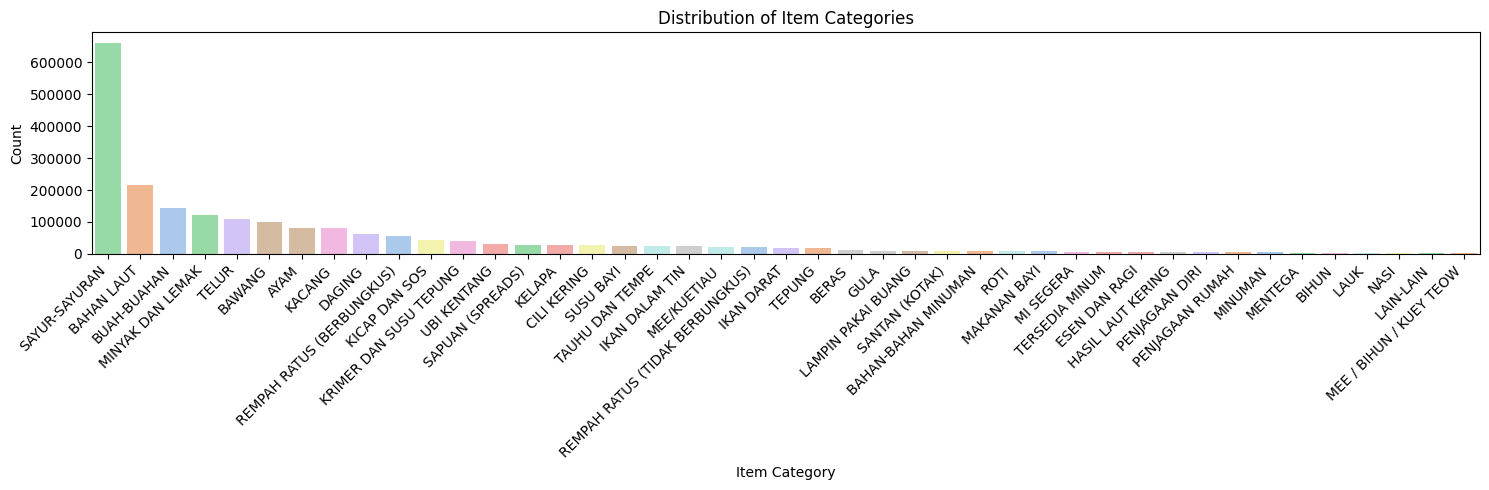

In [43]:
plt.figure(figsize = (15, 5))
sns.countplot(x = 'item_category', data = df_xPK_xBayi_xSiap_xMinuman, order = df_xPK_xBayi_xSiap_xMinuman['item_category'].value_counts().index,
              hue = 'item_category', palette = 'pastel')
plt.xticks(rotation = 45, ha = 'right')
plt.title('Distribution of Item Categories')
plt.xlabel('Item Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### **Price Distribution by Item Category**

C:\Users\hp\AppData\Local\Temp\ipykernel_5804\1312012776.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = average_prices.index, y = average_prices.values, palette = 'pastel')


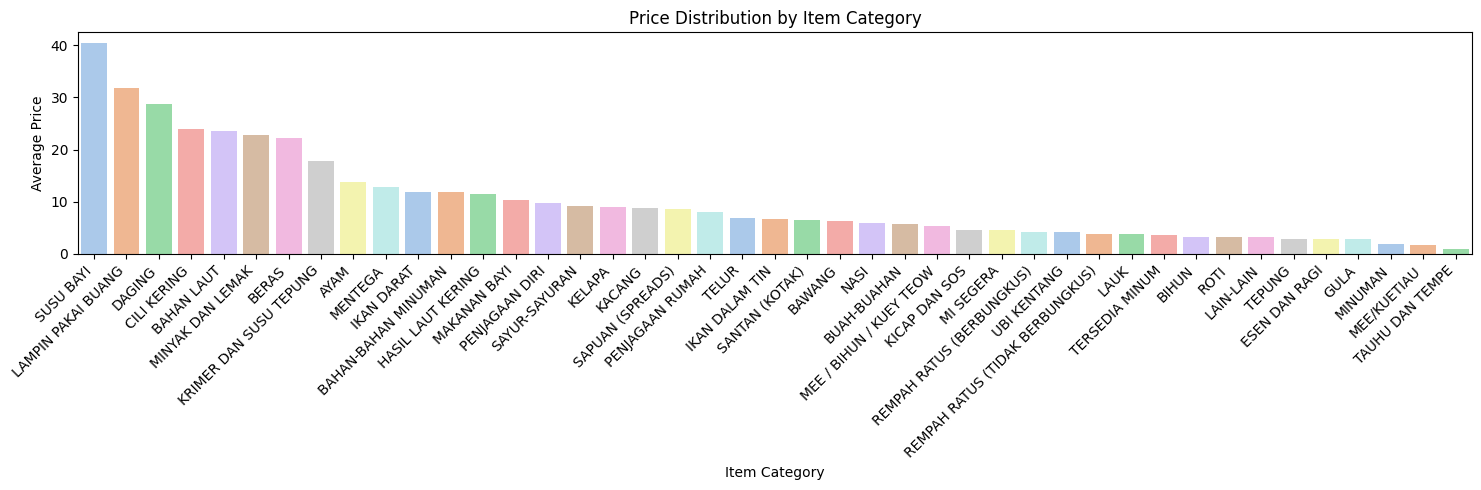

In [44]:
#group the data by district and count the number of premises in each district
average_prices = df_xPK_xBayi_xSiap_xMinuman.groupby('item_category')['price'].mean().sort_values(ascending = False)

plt.figure(figsize = (15, 5))
sns.barplot(x = average_prices.index, y = average_prices.values, palette = 'pastel')
plt.title('Price Distribution by Item Category')
plt.xlabel('Item Category')
plt.ylabel('Average Price')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

### **Top 10 Items with Highest Count in Dataset**

In [45]:
top_10_items = df_xPK_xBayi_xSiap_xMinuman['item'].value_counts().nlargest(10).reset_index()
top_10_items.columns = ['item', 'count']
top_10_items

,item,count
0,TELUR MASIN,28161
1,BAWANG PUTIH IMPORT (CHINA),24713
2,TOMATO,24354
3,TIMUN,24287
4,HALIA BASAH (TUA),24059
5,LOBAK MERAH,23919
6,CILI AKAR HIJAU,23141
7,KUBIS BUNGA (CAULIFLOWER),23041
8,BAWANG BESAR KUNING/HOLLAND,22881
9,LIMAU NIPIS,22774


### **District Ranking by Highest Count**

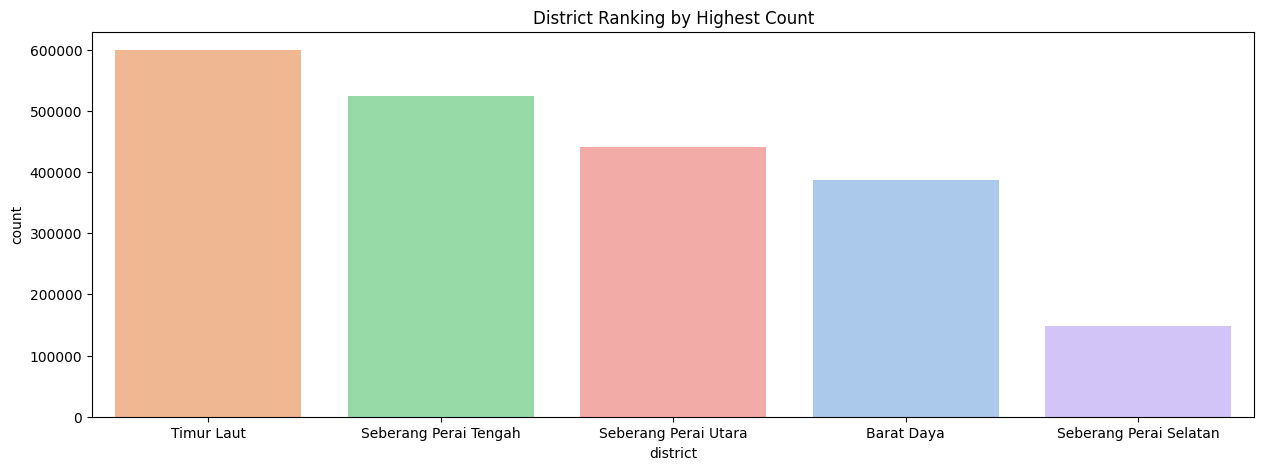

In [46]:
plt.figure(figsize=(15, 5))
sns.countplot(df_xPK_xBayi_xSiap_xMinuman, x = 'district', hue = 'district', order = df_xPK_xBayi_xSiap_xMinuman['district'].value_counts().index)
title = "District Ranking by Highest Count"
plt.title(title)
plt.show()

### **Price Stability for Each Item**

High variance -> price unstable

Low variance -> price stable

In [47]:
#calculate price variance for each item
price_variance = df_xPK_xBayi_xSiap_xMinuman.groupby('item')['price'].var()

#sort by variance and get top 10 highest and lowest
top_10_highest_variance = price_variance.sort_values(ascending = False).head(10)
top_10_lowest_variance = price_variance.sort_values(ascending = True).head(10)

print("\nTop 10 Highest Variance:")
print(top_10_highest_variance)
print("\nTop 10 Lowest Variance:")
print(top_10_lowest_variance)


Top 10 Highest Variance:
item
SOTONG KERING (SAIZ SERDAHANA)          370.100833
MINYAK JAGUNG CAP VECORN                222.490015
MINYAK MASAK SEBATIAN CAP ADELA GOLD    209.754547
MINYAK JAGUNG CAP MAZOLA                203.462824
MINYAK MASAK SEBATIAN CAP NEPTUNE       179.762759
MINYAK MASAK SEBATIAN CAP PISAU         165.112859
MINYAK MASAK SEBATIAN CAP HELANG        164.896761
MINYAK JAGUNG CAP DAISY                 125.282656
MINYAK MASAK TULEN CAP VESAWIT          120.692826
MINYAK MASAK TULEN CAP SAJI             118.246914
Name: price, dtype: float64

Top 10 Lowest Variance:
item
AYAM SOS LEMON                                0.0
UDANG GORENG                                  0.0
KACANG DAL BIASA (INDIA)                      0.0
SERBUK CILI KIJANG                            0.0
IKAN TILAPIA GORENG BIASA (SAIZ SEDERHANA)    0.0
SOTONG MASAK KICAP                            0.0
IKAN SIAKAP TIGA RASA (SAIZ SEDERHANA)        0.0
IKAN SIAKAP MASAM MANIS (SAIZ SEDERHANA)      0.0
I

### **Unique Items for Each District**

In [48]:
#group by item and district, then count the occurrences
item_district_counts = df_xPK_xBayi_xSiap_xMinuman.groupby(['item', 'district']).size().unstack(fill_value=0)

#find items present in only one district
items_in_one_district = item_district_counts[(item_district_counts > 0).sum(axis=1) == 1].reset_index()
items_in_one_district.columns = ['item', 'Barat Daya', 'Seberang Perai Selatan', 'Seberang Perai Tengah', 'Seberang Perai Utara',
                                 'Timur Laut']

print("Items available in only one district:")
items_in_one_district

Items available in only one district:


,item,Barat Daya,Seberang Perai Selatan,Seberang Perai Tengah,Seberang Perai Utara,Timur Laut
0,ANGGUR HIJAU BERBIJI,0,0,0,4,0
1,AYAM SOS LEMON,0,0,0,0,3
2,BABI HIDUP (±100KG / SEEKOR),0,0,1,0,0
3,BAWANG KECIL MERAH IMPORT (MYANMAR),0,0,39,0,0
4,DAGING KAMBING BEBIRI IMPORT BERTULANG (LAMB) ...,0,0,10,0,0
5,DAGING KAMBING BEBIRI IMPORT TANPA TULANG (LAM...,0,0,0,0,8
6,DAGING LEMBU IMPORT (BLADE),0,0,17,0,0
7,DAGING LEMBU IMPORT (CHUCKTENDER),0,0,6,0,0
8,DAGING LEMBU IMPORT (KNUCKLE),0,0,1,0,0
9,DAGING MASAK HALIA,0,0,0,4,0


### **Top 10 Items within Each District**

In [49]:
#group by district and then by item, get the top 10 items within each district
top_10_by_district = df_xPK_xBayi_xSiap_xMinuman.groupby('district')['item'].value_counts().groupby(level = 0).nlargest(10)
top_10_by_district

district                district                item                                               
Barat Daya              Barat Daya              TELUR MASIN                                             5202
                                                TOMATO                                                  4805
                                                TIMUN                                                   4776
                                                BAWANG PUTIH IMPORT (CHINA)                             4713
                                                LOBAK MERAH                                             4623
                                                KUBIS BUNGA (CAULIFLOWER)                               4592
                                                BAWANG BESAR KUNING/HOLLAND                             4508
                                                HALIA BASAH (TUA)                                       4343
                            

### **Number of Premises in Each District**

**Official Residential Data by Goverment**

Seberang Perai Tengah: 422,800

Seberang Perai Utara: 341,300

Seberang Perai Selatan: 185,500

Timur Laut: 551,800

Barat Daya: 239,600

https://www.dosm.gov.my/portal-main/release-content/current-population-estimates-by-administrative-district-

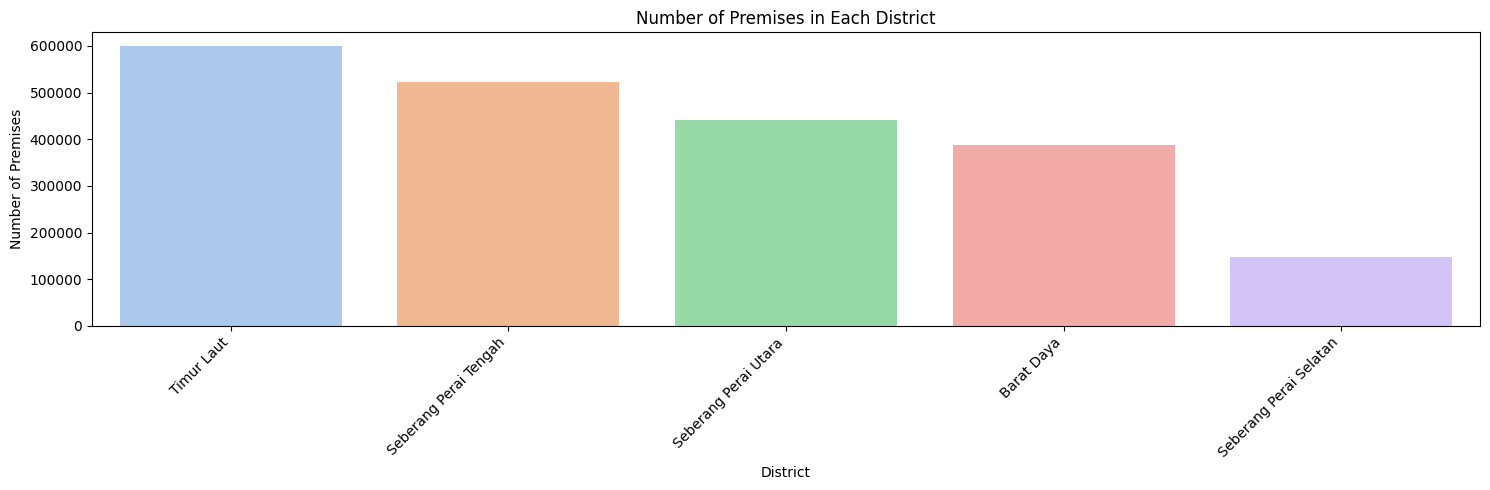

In [50]:
#group the data by district and count the number of premises in each district
district_premise_counts = df_xPK_xBayi_xSiap_xMinuman.groupby('district')['premise'].count().sort_values(ascending = False)

plt.figure(figsize = (15, 5))
sns.barplot(x = district_premise_counts.index, y = district_premise_counts.values, palette = 'pastel', hue = district_premise_counts.index)
plt.title('Number of Premises in Each District')
plt.xlabel('District')
plt.ylabel('Number of Premises')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

### **Top 10 Premise with Highest Count in Dataset**

In [51]:
#get the top 10 premises with the highest count in the dataset
top_10_premises = df_xPK_xBayi_xSiap_xMinuman['premise'].value_counts().nlargest(10)

#put into dataframe
df_top_premises = pd.DataFrame({'premise': top_10_premises.index, 'count': top_10_premises.values})

#merge it with the district to show relationship
top_premises_with_district = pd.merge(df_top_premises, df_premise, on = 'premise', how = 'left')

print(top_premises_with_district[['premise', 'count', 'district']])

                                 premise  count                district
0              MYDIN MALL BUKIT MERTAJAM  38968   Seberang Perai Tengah
1     MYDIN WHOLESALE HYPERMARKET BERTAM  37397    Seberang Perai Utara
2   ECONSAVE CASH & CARRY (JAWI) SDN BHD  36778  Seberang Perai Selatan
3   ECONSAVE CASH & CARRY (ALMA) SDN BHD  36358   Seberang Perai Tengah
4           GIANT HYPERMARKET BAYAN BARU  36004              Barat Daya
5         ECONSAVE CASH & CARRY RAJA UDA  35792    Seberang Perai Utara
6      ECONSAVE CASH & CARRY BUTTERWORTH  35593    Seberang Perai Utara
7              TF VALUE MART BALIK PULAU  35445              Barat Daya
8              PASAR AWAM BUKIT MERTAJAM  35226   Seberang Perai Tengah
9  BILLION SHOPPING CENTRE SEBERANG JAYA  34702   Seberang Perai Tengah


## **Items Selection**

Based on the menu taska provided by Kementerian Kesihatan.

### **Fruits**

Chosen Fruits Items: Banana (Pisang Berangan), Papaya (Betik Biasa)

In [52]:
#view the genres of banana in the dataset
unique_banana_items = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'].str.contains('Pisang', case = False,
                                                                                                   na = False)]['item'].unique()
unique_banana_items

array(['PISANG BERANGAN', 'PISANG EMAS', 'ROTI PISANG'], dtype=object)

In [53]:
#view the counts and select the items that has highest count
for item in unique_banana_items:
  count = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == item]['item'].count()
  print(f"Count of {item}: {count}")

Count of PISANG BERANGAN: 15401
Count of PISANG EMAS: 13476
Count of ROTI PISANG: 53


In [54]:
#View the genres of papaya in the dataset
unique_papaya_items = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'].str.contains('Betik', case = False,
                                                                                                   na = False)]['item'].unique()
unique_papaya_items

array(['BETIK BIASA'], dtype=object)

### **Carbohydrates**

Chosen Carbohydrates Items: Rice (Beras Cap Faiza Emas), Bread (Roti Sandwich Gardenia Original Classic)

Why not using tepung beras or beras pulut as they have higher count than Beras Cap Faiza Emas?

-> because tepung beras is flour and beras pulut is glutinous rice

In [55]:
#view the genres of rice in the dataset
unique_rice_items = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'].str.contains('Beras', case = False,
                                                                                                 na = False)]['item'].unique()
unique_rice_items

array(['TEPUNG BERAS (PELBAGAI JENAMA)', 'BERAS CAP JATI (SST5%)',
       'BERAS CAP FAIZA EMAS (SST5%)', 'BERAS BASMATHI - FAIZA (KASHMIR)',
       'BERAS PULUT THAILAND (SUSU) PELBAGAI JENAMA',
       'BERAS PULUT THAILAND (BIASA) PELBAGAI JENAMA',
       'BERAS CAP RAMBUTAN (SST5%)', 'BERAS CAP JASMINE (SST5%)',
       'BERAS SUPER CAP JATI TWR  5% (IMPORT)',
       'NESTLE CERELAC BERAS MERAH & SUSU - TIN',
       'NESTLE CERELAC BERAS - TIN',
       'BERAS SUPER CAP RAMBUTAN 5% (IMPORT)'], dtype=object)

In [56]:
#view the counts and select the items that has highest count and is rice
for item in unique_rice_items:
  count = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == item]['item'].count()
  print(f"Count of {item}: {count}")

Count of TEPUNG BERAS (PELBAGAI JENAMA): 3745
Count of BERAS CAP JATI (SST5%): 858
Count of BERAS CAP FAIZA EMAS (SST5%): 1665
Count of BERAS BASMATHI - FAIZA (KASHMIR): 1180
Count of BERAS PULUT THAILAND (SUSU) PELBAGAI JENAMA: 1058
Count of BERAS PULUT THAILAND (BIASA) PELBAGAI JENAMA: 1738
Count of BERAS CAP RAMBUTAN (SST5%): 1241
Count of BERAS CAP JASMINE (SST5%): 1539
Count of BERAS SUPER CAP JATI TWR  5% (IMPORT): 428
Count of NESTLE CERELAC BERAS MERAH & SUSU - TIN: 2096
Count of NESTLE CERELAC BERAS - TIN: 2113
Count of BERAS SUPER CAP RAMBUTAN 5% (IMPORT): 1562


In [57]:
#view the genres of bread in the dataset
unique_bread_items = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'].str.contains('Roti', case = False,
                                                                                                  na = False)]['item'].unique()
unique_bread_items

array(['ROTI SANDWICH GARDENIA ORIGINAL CLASSIC',
       'ROTI GARDENIA BREAKTHRU - ROTI GANDUM PENUH',
       'ROTI SANDWICH MASSIMO DENGAN GERMA GANDUM', 'ROTI TELUR',
       'ROTI PISANG', 'ROTI BAWANG', 'ROTI BOOM', 'ROTI TISU',
       'ROTI BAKAR', 'ROTI SARDIN', 'ROTI NAAN', 'ROTI CANAI BIASA'],
      dtype=object)

In [58]:
#view the counts and select the items that has highest count
for item in unique_bread_items:
  count = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == item]['item'].count()
  print(f"Count of {item}: {count}")

Count of ROTI SANDWICH GARDENIA ORIGINAL CLASSIC: 3016
Count of ROTI GARDENIA BREAKTHRU - ROTI GANDUM PENUH: 2799
Count of ROTI SANDWICH MASSIMO DENGAN GERMA GANDUM: 2274
Count of ROTI TELUR: 79
Count of ROTI PISANG: 53
Count of ROTI BAWANG: 76
Count of ROTI BOOM: 75
Count of ROTI TISU: 65
Count of ROTI BAKAR: 59
Count of ROTI SARDIN: 72
Count of ROTI NAAN: 26
Count of ROTI CANAI BIASA: 83


### **Proteins**

Chosen Protein Items: Fish (Ikan Cencaru), Chicken (Ayam Bersih - Standard)

In [59]:
#view the genres of fish in the dataset
unique_fish_items = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'].str.contains('Ikan', case = False,
                                                                                                 na = False)]['item'].unique()
unique_fish_items

array(['IKAN BAWAL HITAM (ANTARA 2 HINGGA 5 EKOR SEKILOGRAM)',
       'IKAN CENCARU (ANTARA 4 HINGGA 6 EKOR SEKILOGRAM)',
       'IKAN SELAR PELATA (≤ 7 EKOR SEKILOGRAM)',
       'IKAN SENANGIN (ANTARA 2 HINGGA 8 EKOR SEKILOGRAM)',
       'SERBUK KARI IKAN BABAS',
       'IKAN KERISI (ANTARA 5 HINGGA 10 EKOR SEKILOGRAM)',
       'IKAN SIAKAP (ANTARA 2 HINGGA 4 EKOR SEKILOGRAM)',
       'IKAN KEMBUNG (ANTARA 8 HINGGA 12 EKOR SEKILOGRAM)',
       'SERBUK KARI IKAN ALAGAPPAS', 'IKAN PARI (KEPINGAN)',
       'IKAN SELAYANG/SARDIN  (≥ 13 EKOR SEKILOGRAM)',
       'PERENCAH NASI GORENG IKAN BILIS SERI AJI',
       'IKAN MERAH (b\t% 1 KILOGRAM SEEKOR)',
       'IKAN TONGKOL/AYA/KAYU HITAM (ANTARA 1 HINGGA 2 EKOR SEKILOGRAM)',
       'IKAN JENAHAK (b\t% 1 KILOGRAM SEEKOR)',
       'IKAN TENGGIRI BATANG (KEPINGAN)',
       'IKAN MABUNG (ANTARA 6 HINGGA 10 EKOR SEKILOGRAM)',
       'IKAN MERAH (KEPINGAN)', 'SERBUK KARI IKAN (TIDAK BERBUNGKUS)',
       'SERBUK KARI IKAN ADABI', 'IKAN JENAHAK (KEP

In [60]:
#view the counts and select the items that has highest count
for item in unique_fish_items:
  count = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == item]['item'].count()
  print(f"Count of {item}: {count}")

Count of IKAN BAWAL HITAM (ANTARA 2 HINGGA 5 EKOR SEKILOGRAM): 12443
Count of IKAN CENCARU (ANTARA 4 HINGGA 6 EKOR SEKILOGRAM): 17632
Count of IKAN SELAR PELATA (≤ 7 EKOR SEKILOGRAM): 7687
Count of IKAN SENANGIN (ANTARA 2 HINGGA 8 EKOR SEKILOGRAM): 4998
Count of SERBUK KARI IKAN BABAS: 4504
Count of IKAN KERISI (ANTARA 5 HINGGA 10 EKOR SEKILOGRAM): 12129
Count of IKAN SIAKAP (ANTARA 2 HINGGA 4 EKOR SEKILOGRAM): 10827
Count of IKAN KEMBUNG (ANTARA 8 HINGGA 12 EKOR SEKILOGRAM): 9629
Count of SERBUK KARI IKAN ALAGAPPAS: 2692
Count of IKAN PARI (KEPINGAN): 9166
Count of IKAN SELAYANG/SARDIN  (≥ 13 EKOR SEKILOGRAM): 16920
Count of PERENCAH NASI GORENG IKAN BILIS SERI AJI: 1820
Count of IKAN MERAH (b	% 1 KILOGRAM SEEKOR): 3290
Count of IKAN TONGKOL/AYA/KAYU HITAM (ANTARA 1 HINGGA 2 EKOR SEKILOGRAM): 14235
Count of IKAN JENAHAK (b	% 1 KILOGRAM SEEKOR): 3377
Count of IKAN TENGGIRI BATANG (KEPINGAN): 4131
Count of IKAN MABUNG (ANTARA 6 HINGGA 10 EKOR SEKILOGRAM): 6869
Count of IKAN MERAH (KEPIN

In [61]:
#view the genres of chicken in the dataset
unique_chicken_items = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'].str.contains('Ayam', case = False,
                                                                                                    na = False)]['item'].unique()
unique_chicken_items

array(['TELUR AYAM GRED A (BERAT 65.0 GM HINGGA 69.9 GM SEBIJI)',
       'TELUR AYAM GRED B (BERAT 60.0 GM HINGGA 64.9 GM)',
       'TELUR AYAM GRED C (BERAT 55.0 GM HINGGA 59.9 GM SEBIJI)',
       'SARDIN CAP AYAM (SOS TOMATO)', 'TELUR AYAM GRED A',
       'TELUR AYAM GRED B', 'TELUR AYAM GRED C', 'WHOLE LEG AYAM',
       'BAYAM HIJAU', 'BAYAM MERAH', 'KEPAK AYAM (CHICKEN WING) (1KG)',
       'TELUR AYAM KAMPUNG', 'AYAM BERSIH - STANDARD',
       'MACKAREL CAP AYAM (SOS TOMATO)',
       'SANTAN KELAPA JENAMA AYAM BRAND', 'PAHA AYAM (CHICKEN DRUMSTICK)',
       'DADA AYAM (CHICKEN KEEL) (1KG)', 'THIGH AYAM',
       'SERBUK KARI AYAM DAN DAGING ADABI',
       'SERBUK KURMA AYAM & DAGING ADABI',
       'TUNA CAP AYAM (TUNA MAYONNAISE)', 'CINTAN MI SEGERA PERISA AYAM',
       'AYAM BERSIH - SUPER', 'AYAM BELANDA IMPORT', 'NASI GORENG AYAM',
       'TOM YAM AYAM', 'NASI + SAYUR + AYAM', 'AYAM GORENG',
       'AYAM MASAK MERAH', 'SUP AYAM', 'NASI BRIYANI AYAM',
       'AYAM MASAK KARI', 'Ay

In [62]:
#view the counts and select the items that has highest count
for item in unique_chicken_items:
  count = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == item]['item'].count()
  print(f"Count of {item}: {count}")

Count of TELUR AYAM GRED A (BERAT 65.0 GM HINGGA 69.9 GM SEBIJI): 6945
Count of TELUR AYAM GRED B (BERAT 60.0 GM HINGGA 64.9 GM): 8667
Count of TELUR AYAM GRED C (BERAT 55.0 GM HINGGA 59.9 GM SEBIJI): 5779
Count of SARDIN CAP AYAM (SOS TOMATO): 7808
Count of TELUR AYAM GRED A: 8796
Count of TELUR AYAM GRED B: 10409
Count of TELUR AYAM GRED C: 7815
Count of WHOLE LEG AYAM: 13757
Count of BAYAM HIJAU: 19853
Count of BAYAM MERAH: 8829
Count of KEPAK AYAM (CHICKEN WING) (1KG): 16250
Count of TELUR AYAM KAMPUNG: 13574
Count of AYAM BERSIH - STANDARD: 21724
Count of MACKAREL CAP AYAM (SOS TOMATO): 5954
Count of SANTAN KELAPA JENAMA AYAM BRAND: 2935
Count of PAHA AYAM (CHICKEN DRUMSTICK): 10725
Count of DADA AYAM (CHICKEN KEEL) (1KG): 10044
Count of THIGH AYAM: 7833
Count of SERBUK KARI AYAM DAN DAGING ADABI: 2342
Count of SERBUK KURMA AYAM & DAGING ADABI: 2306
Count of TUNA CAP AYAM (TUNA MAYONNAISE): 2713
Count of CINTAN MI SEGERA PERISA AYAM: 1454
Count of AYAM BERSIH - SUPER: 2014
Count o

### **Vegetables**

Chosen Vegetables Items: Carrots (Lobak Merah), Tomato, Cauliflower (Kubis Bunga (Cauliflower))

In [63]:
#view the genres of carrots in the dataset
unique_carrot_items = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'].str.contains('Lobak', case = False,
                                                                                                   na = False)]['item'].unique()
unique_carrot_items

array(['LOBAK MERAH'], dtype=object)

In [64]:
#view the genres of tomato in the dataset
unique_tomato_items = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'].str.contains('Tomato', case = False,
                                                                                                   na = False)]['item'].unique()
unique_tomato_items

array(['TOMATO', 'SARDIN CAP AYAM (SOS TOMATO)',
       'MACKAREL CAP AYAM (SOS TOMATO)', 'SOS TOMATO MAGGI',
       'SOS TOMATO LIFE', 'SARDIN CAP KING CUP (SOS TOMATO)',
       'MACKAREL CAP KING CUP (SOS TOMATO)',
       'SARDIN CAP ADABI (SOS TOMATO DENGAN CILI)'], dtype=object)

In [65]:
#view the genres of cauliflower in the dataset
unique_cauliflower_items = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'].str.contains('Kubis Bunga', case = False,
                                                                                                        na = False)]['item'].unique()
unique_cauliflower_items

array(['KUBIS BUNGA (CAULIFLOWER)'], dtype=object)

### **Dairy**

Chosen Dairy Items: Milk (Susu Tepung Segera Everyday)

In [66]:
#view the genres of milk in the dataset
unique_milk_items = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'].str.contains('Susu', case = False,
                                                                                                 na = False)]['item'].unique()
unique_milk_items

array(['TEMBIKAI SUSU', 'SUSU SEGAR DUTCH LADY', 'SUSU MARIGOLD HL',
       'LACTOGEN 2 RUMUSAN SUSULAN (KOTAK)',
       "SUSU TEPUNG ISIAN KURANG LEMAK 'OMEGA PLUS'",
       'SUSU TEPUNG SEGERA FERNLEAF (INSTANT)',
       'SUSU ANLENE ACTIFIT 3X PERISA ASLI', 'SUSU ANLENE GOLD 5X',
       'SUSU TEPUNG SEGERA EVERYDAY', 'SUSU TEPUNG PENUH KRIM DUTCHLADY',
       'SUSU ANLENE ACTIFIT 3X COKLAT',
       'BERAS PULUT THAILAND (SUSU) PELBAGAI JENAMA',
       'SUSU TEPUNG SEGERA DUTCHLADY (BIASA )',
       'NESTLE CERELAC BERAS MERAH & SUSU - TIN',
       'NAN PRO LANGKAH 2 RUMUSAN SUSULAN (KOTAK)',
       'SUSU SEGAR FARM FRESH', 'SUSU SEGAR KURMA FARM FRESH',
       'DUMEX DUPRO 2 (RUMUSAN SUSULAN)',
       'SUSU SEJAT PENUH KRIM CAP IDEAL',
       'SUSU ISIAN PEKAT MANIS CAP F & N',
       'SUSU TEPUNG PENUH KRIM SEGERA NESPRAY', 'CARROT SUSU'],
      dtype=object)

In [67]:
#view the counts and select the items that has highest count
for item in unique_milk_items:
  count = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == item]['item'].count()
  print(f"Count of {item}: {count}")

Count of TEMBIKAI SUSU: 8610
Count of SUSU SEGAR DUTCH LADY: 298
Count of SUSU MARIGOLD HL: 545
Count of LACTOGEN 2 RUMUSAN SUSULAN (KOTAK): 2218
Count of SUSU TEPUNG ISIAN KURANG LEMAK 'OMEGA PLUS': 3923
Count of SUSU TEPUNG SEGERA FERNLEAF (INSTANT): 1607
Count of SUSU ANLENE ACTIFIT 3X PERISA ASLI: 2695
Count of SUSU ANLENE GOLD 5X: 2703
Count of SUSU TEPUNG SEGERA EVERYDAY: 4446
Count of SUSU TEPUNG PENUH KRIM DUTCHLADY: 1630
Count of SUSU ANLENE ACTIFIT 3X COKLAT: 2414
Count of BERAS PULUT THAILAND (SUSU) PELBAGAI JENAMA: 1058
Count of SUSU TEPUNG SEGERA DUTCHLADY (BIASA ): 1633
Count of NESTLE CERELAC BERAS MERAH & SUSU - TIN: 2096
Count of NAN PRO LANGKAH 2 RUMUSAN SUSULAN (KOTAK): 945
Count of SUSU SEGAR FARM FRESH: 297
Count of SUSU SEGAR KURMA FARM FRESH: 232
Count of DUMEX DUPRO 2 (RUMUSAN SUSULAN): 1913
Count of SUSU SEJAT PENUH KRIM CAP IDEAL: 1567
Count of SUSU ISIAN PEKAT MANIS CAP F & N: 960
Count of SUSU TEPUNG PENUH KRIM SEGERA NESPRAY: 1123
Count of CARROT SUSU: 129


## **Item Selected**

Price Over Time for Each Item Selected: Different premise has different price for each items, however the darker lines indicates that multiple premises has the same price for the specific items.

#### **Functions Defining**

##### **replace_outliers_with_median**

In [68]:
def replace_outliers_with_median(df, column_name):
    # Calculate Q1 and Q3
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Define bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Create a copy to avoid modifying the original DataFrame
    df_cleaned = df.copy()

    # Replace outliers with the median
    median_value = df[column_name].median()
    df_cleaned.loc[(df_cleaned[column_name] < lower_bound) | (df_cleaned[column_name] > upper_bound), column_name] = median_value

    return df_cleaned

### **Banana**

In [69]:
df_banana = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == 'PISANG BERANGAN']

#### **Price of Banana Over Time**

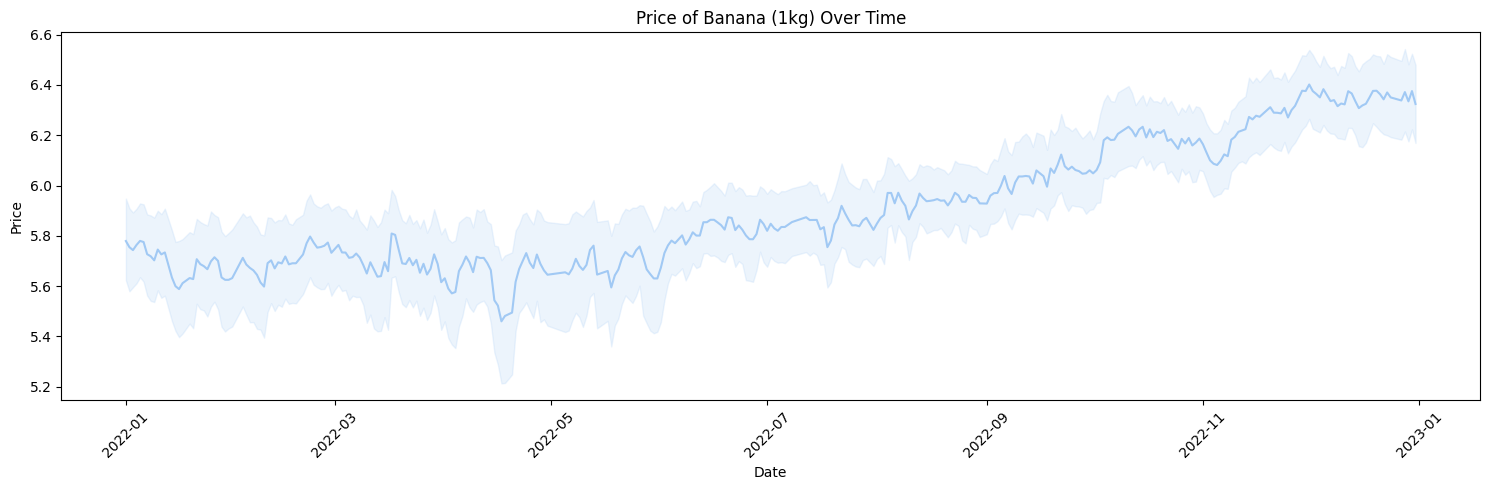

In [70]:
#retrieve data that contains only the selected banana in df_xPK_xBayi_xSiap_xMinuman
plt.figure(figsize = (15, 5))
sns.lineplot(x = 'date', y = 'price', data = df_banana)
plt.title('Price of Banana (1kg) Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Price of Banana is relatively stable compared to the other fruits or vegetables.

https://www.hmetro.com.my/agro/2022/01/797926/tanaman-paling-mudah-diusahakan

#### **Boxplot of Banana Price**

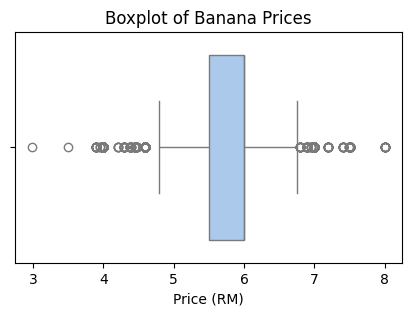

In [71]:
plt.figure(figsize=(5, 3))
sns.boxplot(x=df_banana['price'])
plt.title('Boxplot of Banana Prices')
plt.xlabel('Price (RM)')
plt.show()

Conclusion: Price stable but left skewed, use median to replace the outliers.

#### **Outliers Handling**

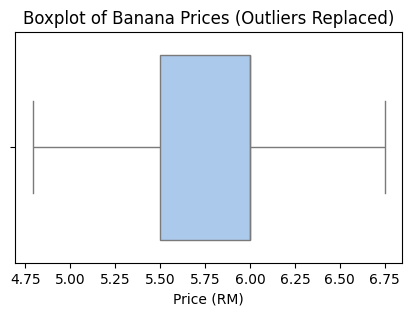

In [72]:
df_banana = replace_outliers_with_median(df_banana, 'price')

plt.figure(figsize=(5, 3))
sns.boxplot(x=df_banana['price'])
plt.title('Boxplot of Banana Prices (Outliers Replaced)')
plt.xlabel('Price (RM)')
plt.show()

### **Papaya**

In [73]:
#retrieve data that contains only the selected papaya in df_xPK_xBayi_xSiap_xMinuman
df_papaya = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == 'BETIK BIASA']

#### **Price of Papaya Over Time**

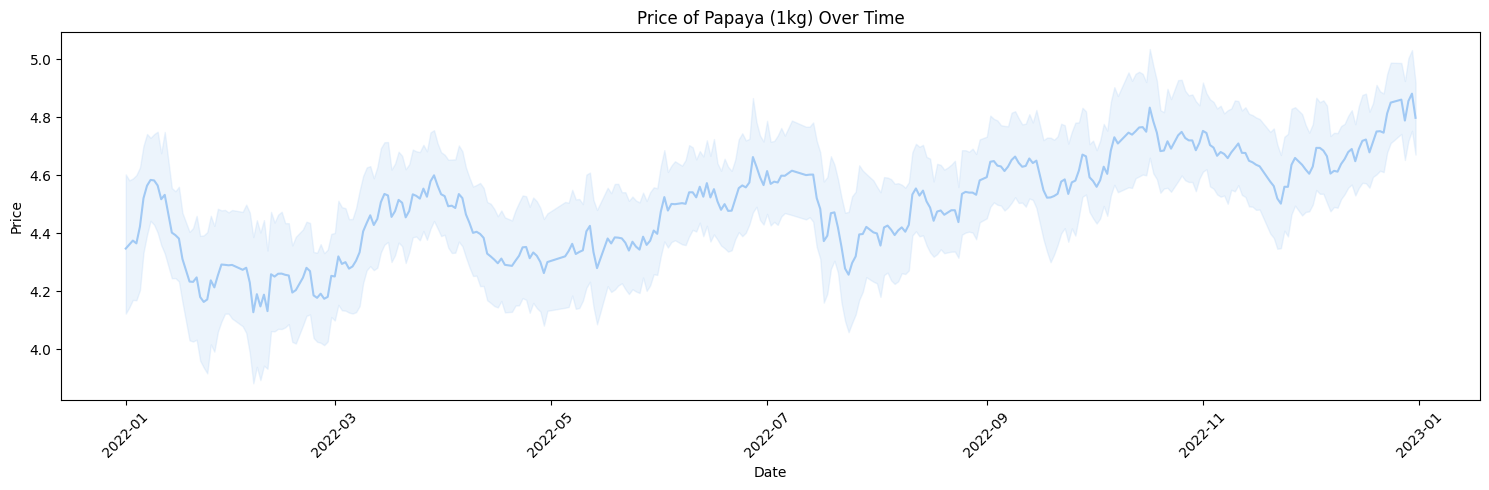

In [74]:
plt.figure(figsize=(15, 5))
sns.lineplot(x = 'date', y = 'price', data = df_papaya)
plt.title('Price of Papaya (1kg) Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

January: Flood Happened

https://www.channelnewsasia.com/asia/malaysia-johor-flood-heat-rising-vegetable-prices-cny-2461066

March: Price rise due to climate issue that cause papaya's yield dropped.

https://penang.chinapress.com.my/20220311/%E4%BA%A7%E9%87%8F%E5%B0%91-%E6%9C%A8%E7%93%9C%E4%BB%B7%E6%B6%A860/


*   high costs of production stemming from higher expenditures for labour and inputs, as well as by a limited availability of labour
*   bacterial plant diseases

https://openknowledge.fao.org/server/api/core/bitstreams/852265a4-9006-4d54-a792-51f1d9c44673/content


### **Rice**

In [75]:
#retrieve data that contains only the selected rice in df_xPK_xBayi_xSiap_xMinuman
df_rice = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == 'BERAS CAP FAIZA EMAS (SST5%)']

#### **Price of Rice Over Time**

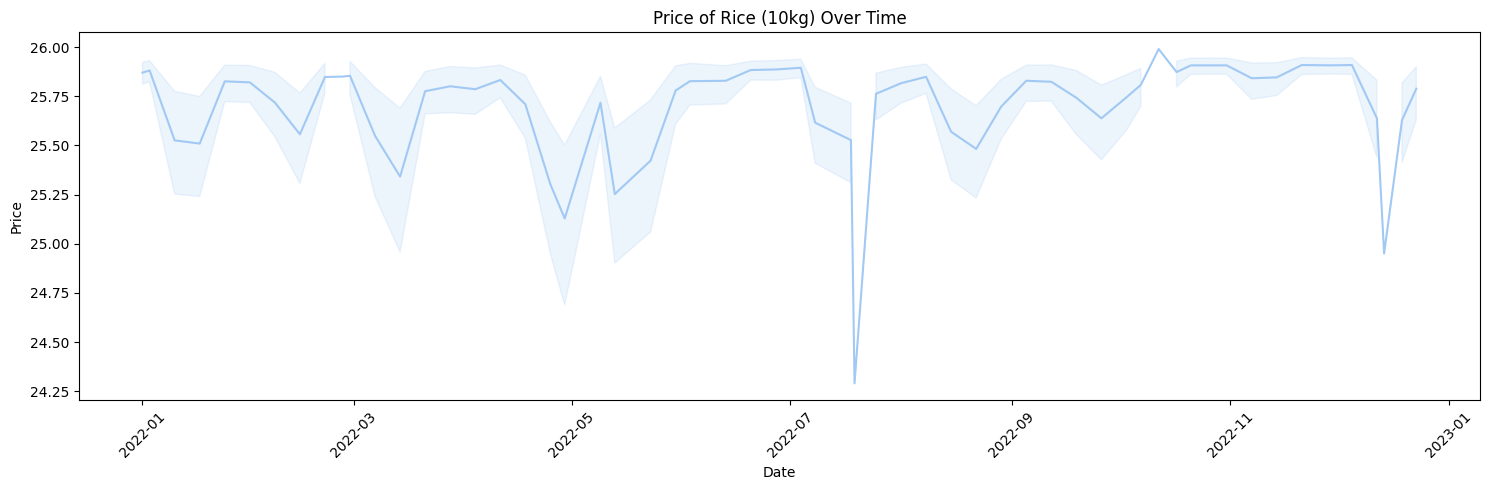

In [76]:
plt.figure(figsize = (15, 5))
sns.lineplot(x = 'date', y = 'price', data = df_rice)
plt.title('Price of Rice (10kg) Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Price of Rice is relatively stable in Malaysia according to Ministry of Agriculture and Food Industries (MAFI).

https://www.bernas.com.my/component/content/article/78-1-aug-2022-malaysia-s-rice-supply-stable-enough-to-meet-people-s-needs?catid=37&Itemid=107

#### **Boxplot of Rice Price**

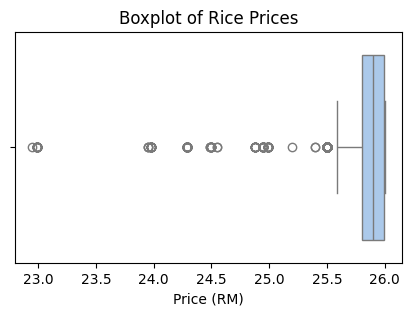

In [77]:
plt.figure(figsize=(5, 3))
sns.boxplot(x=df_rice['price'])
plt.title('Boxplot of Rice Prices')
plt.xlabel('Price (RM)')
plt.show()

Conclusion: Price stable but left skewed, use median to replace the outliers.

#### **Outliers Handling**

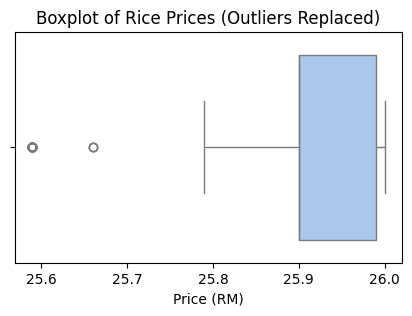

In [78]:
df_rice = replace_outliers_with_median(df_rice, 'price')

plt.figure(figsize=(5, 3))
sns.boxplot(x=df_rice['price'])
plt.title('Boxplot of Rice Prices (Outliers Replaced)')
plt.xlabel('Price (RM)')
plt.show()

Outliers still exist, thus replace it with median again.

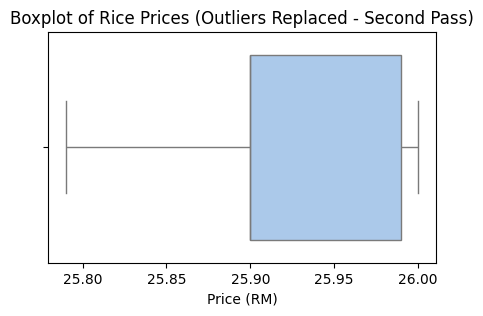

In [79]:
df_rice = replace_outliers_with_median(df_rice, 'price')

plt.figure(figsize=(5, 3))
sns.boxplot(x=df_rice['price'])
plt.title('Boxplot of Rice Prices (Outliers Replaced - Second Pass)')
plt.xlabel('Price (RM)')
plt.show()

### **Bread**

In [80]:
#retrieve data that contains only the selected bread in df_xPK_xBayi_xSiap_xMinuman
df_bread = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == 'ROTI SANDWICH GARDENIA ORIGINAL CLASSIC']

#### **Price of Bread Over Time**

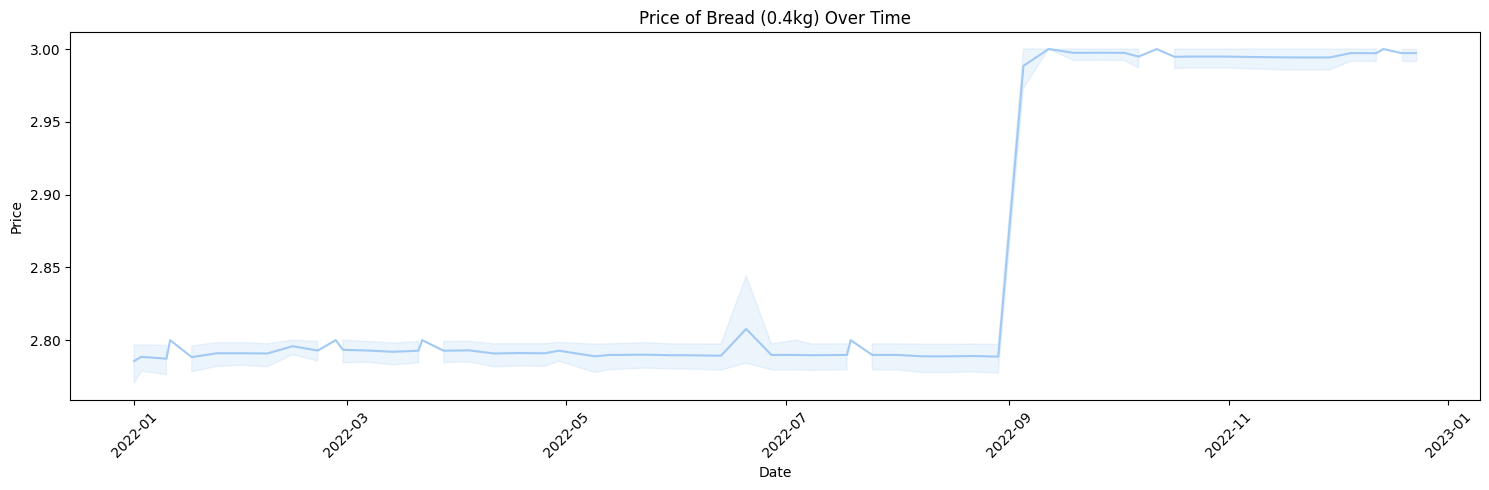

In [81]:
plt.figure(figsize = (15, 5))
sns.lineplot(x = 'date', y = 'price', data = df_bread)
plt.title('Price of Bread (0.4kg) Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Gardenia Bakeries (KL) Sdn Bhd said the company had no alternative but to increase its prices due to a hike in costs of raw materials such as wheat flour and vegetable fat, after making every effort to maintain prices.

https://www.thestar.com.my/news/nation/2022/08/28/gardenia-products-to-cost-more-from-sept-1

#### **Boxplot of Bread Price**

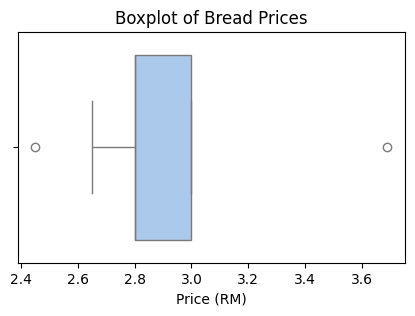

In [82]:
plt.figure(figsize=(5, 3))
sns.boxplot(x=df_bread['price'])
plt.title('Boxplot of Bread Prices')
plt.xlabel('Price (RM)')
plt.show()

Conclusion: Price stable but right skewed, use median to replace the outliers.

#### **Outliers Handling**

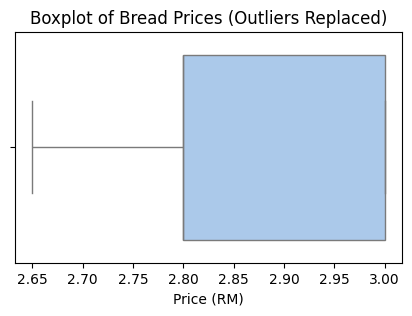

In [83]:
df_bread = replace_outliers_with_median(df_bread, 'price')

plt.figure(figsize=(5, 3))
sns.boxplot(x=df_bread['price'])
plt.title('Boxplot of Bread Prices (Outliers Replaced)')
plt.xlabel('Price (RM)')
plt.show()

### **Fish**

In [84]:
#retrieve data that contains only the selected fish in df_xPK_xBayi_xSiap_xMinuman
df_fish = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == 'IKAN CENCARU (ANTARA 4 HINGGA 6 EKOR SEKILOGRAM)']

#### **Price of Fish Over Time**

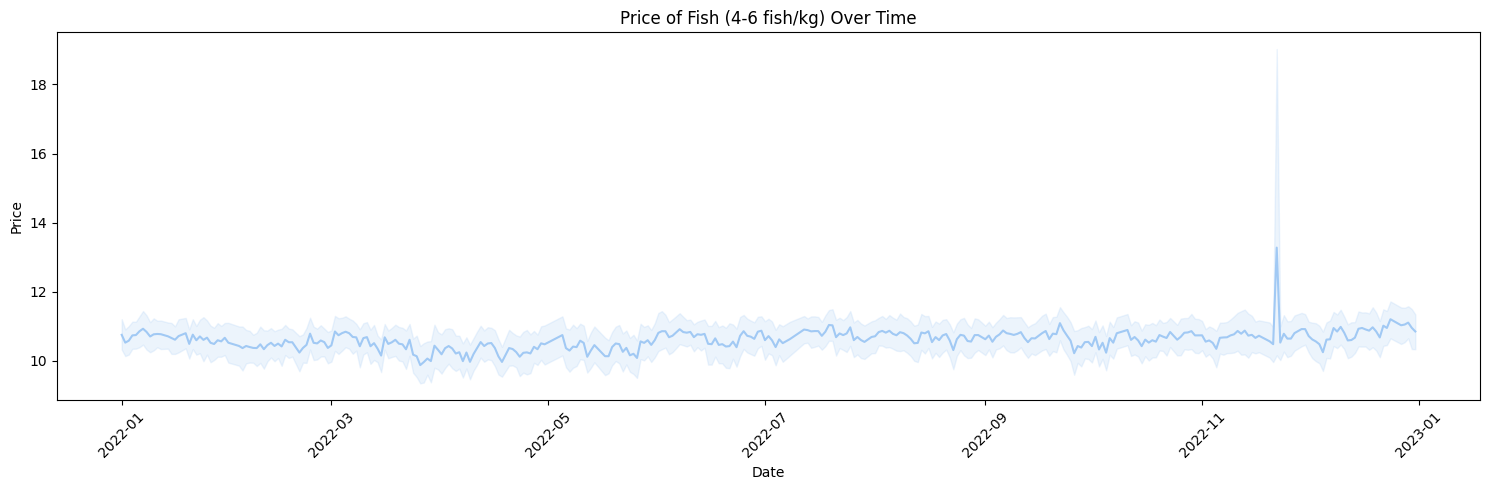

In [85]:
plt.figure(figsize = (15, 5))
sns.lineplot(x = 'date', y = 'price', data = df_fish)
plt.title('Price of Fish (4-6 fish/kg) Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

#### **Boxplot of Fish Price**

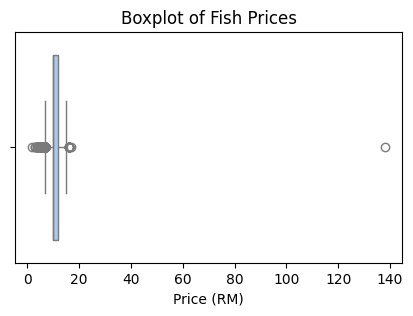

In [86]:
plt.figure(figsize=(5, 3))
sns.boxplot(x=df_fish['price'])
plt.title('Boxplot of Fish Prices')
plt.xlabel('Price (RM)')
plt.show()

Conclusion: Price stable but right skewed, use median to replace the outliers.

#### **Outliers Handling**

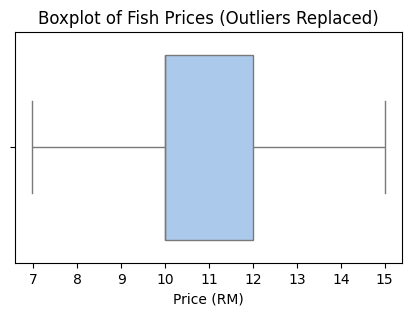

In [87]:
df_fish = replace_outliers_with_median(df_fish, 'price')

plt.figure(figsize=(5, 3))
sns.boxplot(x=df_fish['price'])
plt.title('Boxplot of Fish Prices (Outliers Replaced)')
plt.xlabel('Price (RM)')
plt.show()

### **Chicken**

In [88]:
#retrieve data that contains only the selected chicken in df_xPK_xBayi_xSiap_xMinuman
df_chicken = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == 'AYAM BERSIH - STANDARD']

#### **Price of Chicken Over Time**

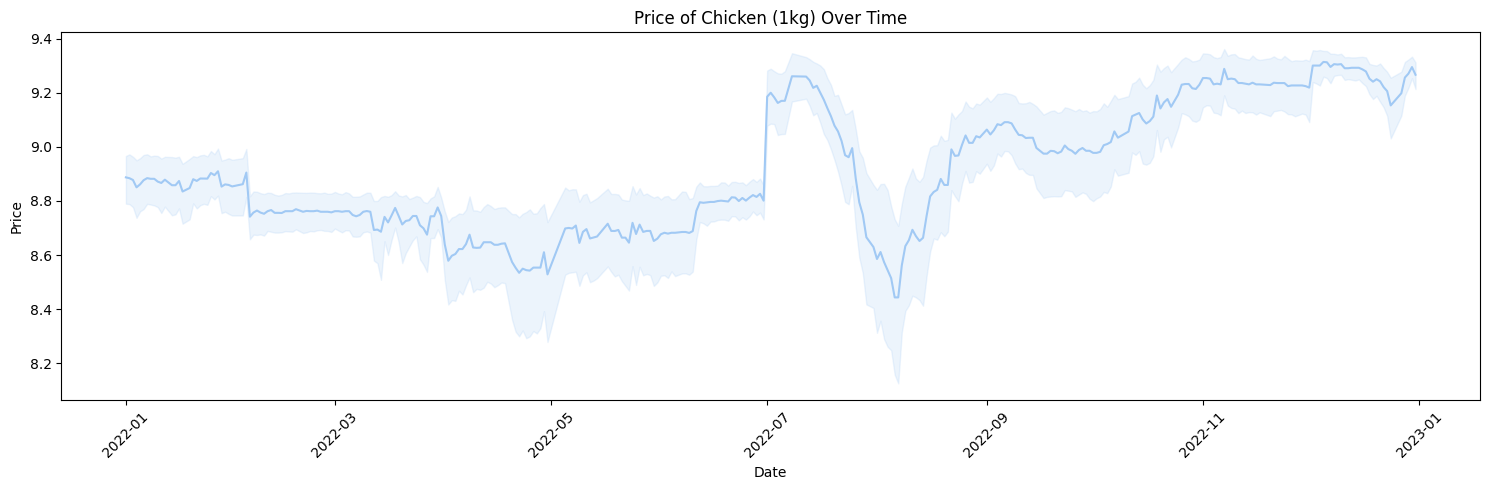

In [89]:
plt.figure(figsize = (15, 5))
sns.lineplot(x = 'date', y = 'price', data = df_chicken)
plt.title('Price of Chicken (1kg) Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Government has fixed a retail ceiling price for chicken of RM8.90 a kg, effective from Feb 5 to June 5, results in a relatively stable chicken price during this period.

https://www.straitstimes.com/asia/se-asia/chicken-being-sold-at-double-the-price-in-malaysia

The new ceiling price for chicken has been set at RM9.40 per kg which is 50 sen higher than the previous level at RM8.90 in Peninsular Malaysia starting from July 1.

https://theedgemalaysia.com/article/new-ceiling-price-chicken-rm940-kg-starting-july-1

The reason of price increasing includes the workforce issue caused by pandemic, the price of chicken feed (corn, wheat, barley, and soybean) affected by the war in Ukraine as almost all of the livestock feed in Malaysia are imported from overseas.

https://www.freemalaysiatoday.com/category/leisure/money/2022/08/10/why-have-chicken-prices-increased-in-malaysia

#### **Boxplot of Chicken Price**

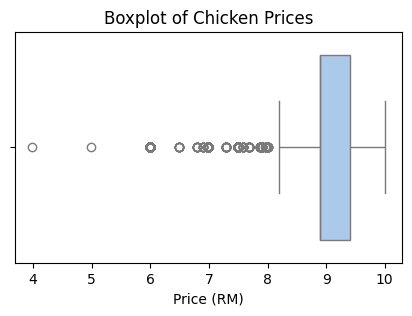

In [90]:
plt.figure(figsize=(5, 3))
sns.boxplot(x=df_chicken['price'])
plt.title('Boxplot of Chicken Prices')
plt.xlabel('Price (RM)')
plt.show()

Conclusion: Price stable but left skewed, use median to replace the outliers.

#### **Outliers Handling**

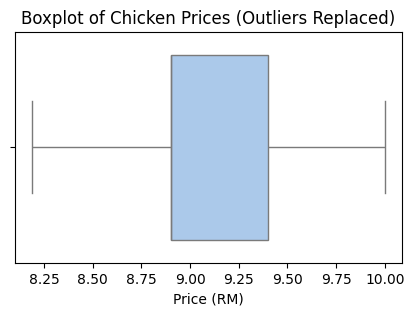

In [91]:
df_chicken = replace_outliers_with_median(df_chicken, 'price')

plt.figure(figsize=(5, 3))
sns.boxplot(x=df_chicken['price'])
plt.title('Boxplot of Chicken Prices (Outliers Replaced)')
plt.xlabel('Price (RM)')
plt.show()

### **Carrot**

In [92]:
#retrieve data that contains only the selected carrot in df_xPK_xBayi_xSiap_xMinuman
df_carrot = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == 'LOBAK MERAH']

#### **Price of Carrot Over Time**

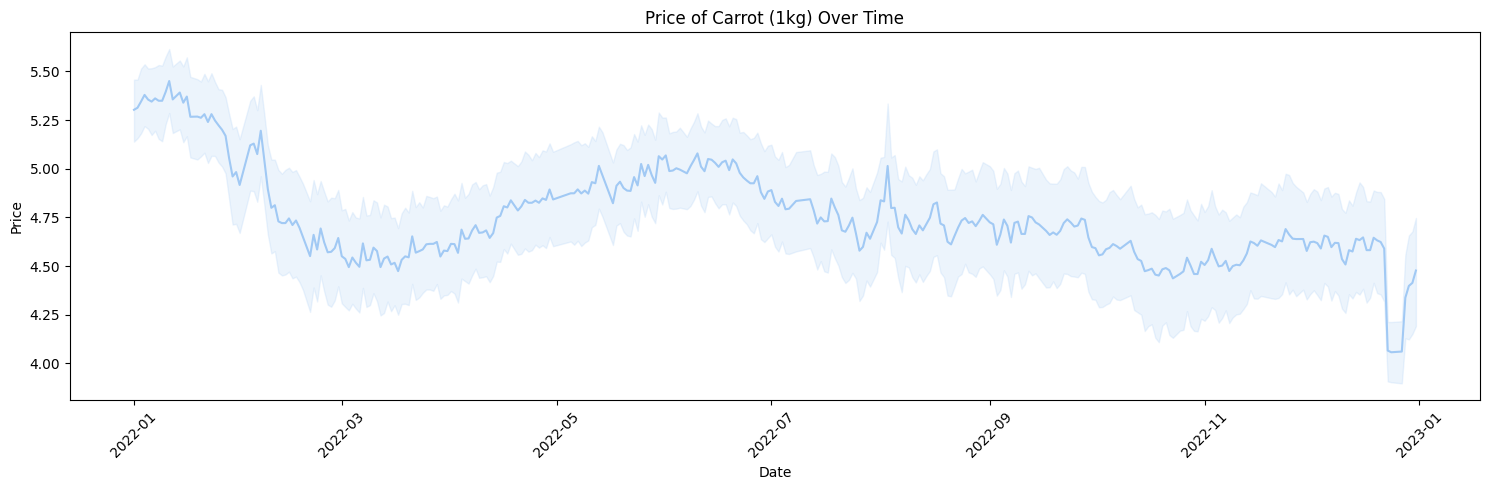

In [93]:
plt.figure(figsize = (15, 5))
sns.lineplot(x = 'date', y = 'price', data = df_carrot)
plt.title('Price of Carrot (1kg) Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

The Department of Statistics Malaysia (DOSM) reported a 5.1% increase in the vegetable subgroup of the Consumer Price Index (CPI) in March 2022. This rise was attributed to higher costs of inputs like fertilizers and pesticides, exacerbated by the Russia-Ukraine conflict, which disrupted global supply chains and increased production costs.

https://theedgemalaysia.com/article/vegetable-chicken-price-spikes-feed-malaysias-food-inflation-march-yearonyear-cpi-rise?utm_source=chatgpt.com

### **Tomato**

In [94]:
#retrieve data that contains only the selected tomato in df_xPK_xBayi_xSiap_xMinuman
df_tomato = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == 'TOMATO']

#### **Price of Tomato Over Time**

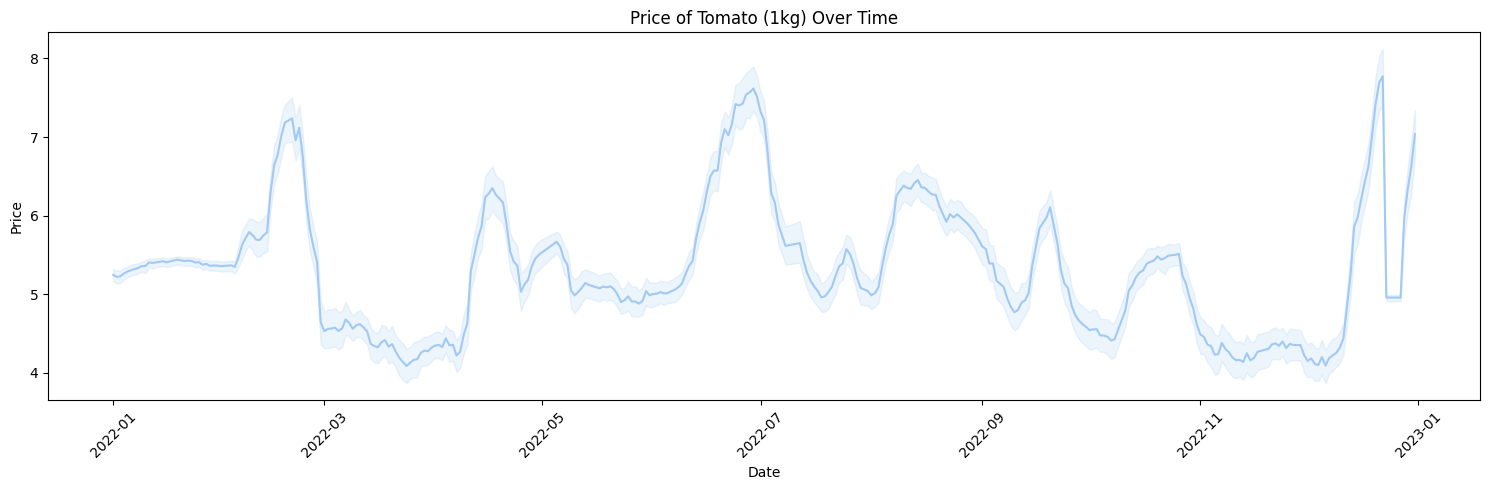

In [95]:
plt.figure(figsize = (15, 5))
sns.lineplot(x = 'date', y = 'price', data = df_tomato)
plt.title('Price of Tomato (1kg) Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Feb: supply shortages and high demand.

https://selangorjournal.my/2024/02/supply-shortages-high-demand-driving-up-tomato-prices-ministry/?utm_source=chatgpt.com

November 19: General Election, price drops

### **Cauliflower**

In [96]:
#retrieve data that contains only the selected cauliflower in df_xPK_xBayi_xSiap_xMinuman
df_cauliflower = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == 'KUBIS BUNGA (CAULIFLOWER)']

#### **Price of Cauliflower Over Time**

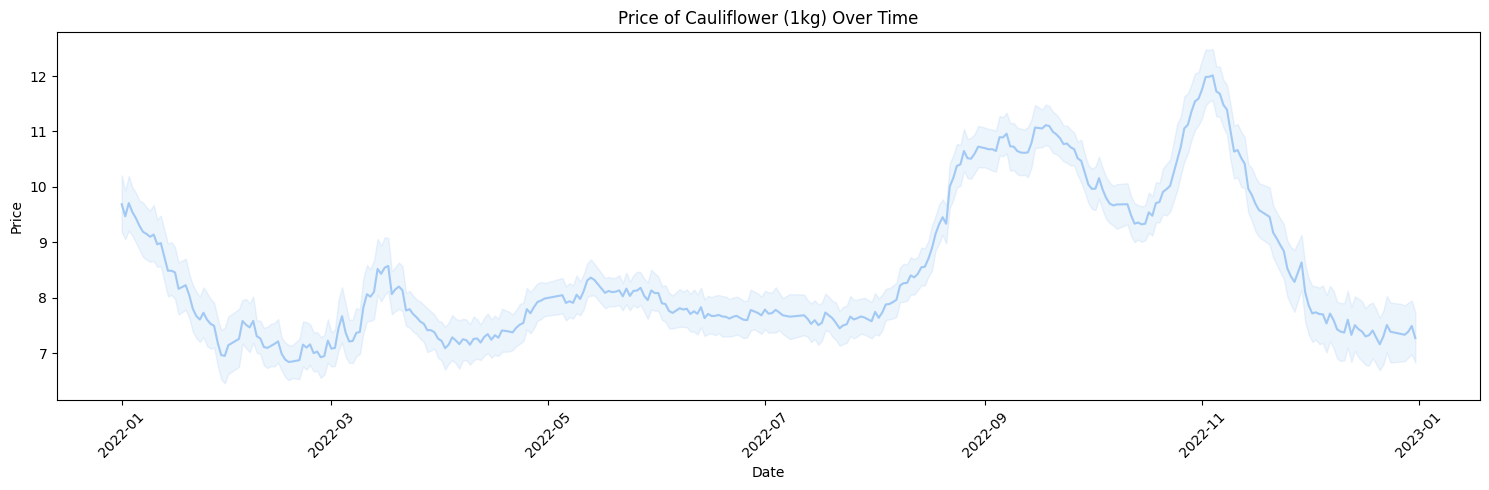

In [97]:
plt.figure(figsize = (15, 5))
sns.lineplot(x = 'date', y = 'price', data = df_cauliflower)
plt.title('Price of Cauliflower (1kg) Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Higher price in January due to weather conditions affecting both local and imported supplies, as well as increased logistics costs.

https://www.malaymail.com/news/malaysia/2021/11/23/almost-200pc-hike-in-vegetable-prices-in-penang-due-to-weather-say-authorit/2023080?utm_source=chatgpt.com

### **Milk**

In [98]:
#retrieve data that contains only the selected milk in df_xPK_xBayi_xSiap_xMinuman
df_milk = df_xPK_xBayi_xSiap_xMinuman[df_xPK_xBayi_xSiap_xMinuman['item'] == 'SUSU TEPUNG SEGERA EVERYDAY']

#### **Price of Milk Over Time**

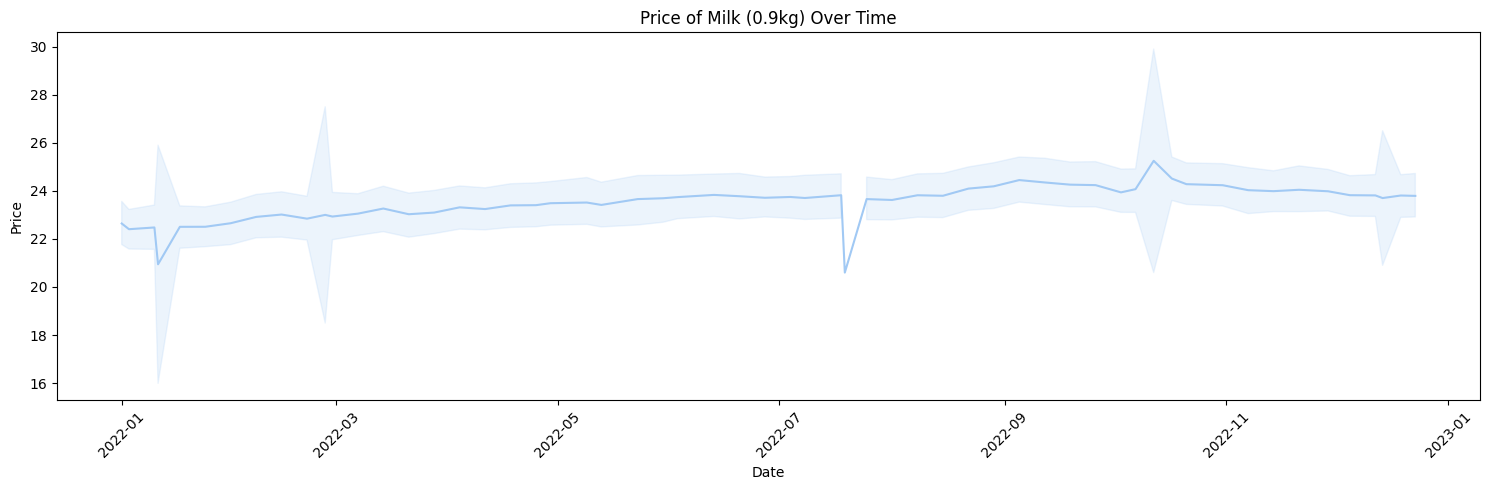

In [99]:
plt.figure(figsize = (15, 5))
sns.lineplot(x = 'date', y = 'price', data = df_milk)
plt.title('Price of Milk (0.9kg) Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Price of Milk is relatively stable.

#### **Boxplot of Milk Price**

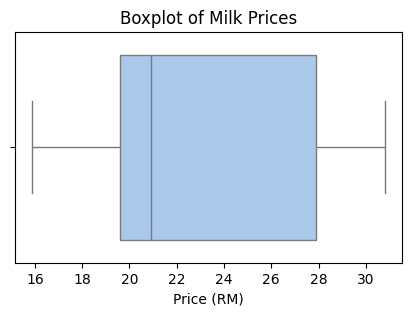

In [100]:
plt.figure(figsize=(5, 3))
sns.boxplot(x=df_milk['price'])
plt.title('Boxplot of Milk Prices')
plt.xlabel('Price (RM)')
plt.show()

Conclusion: No outliers

## **Price Distribution for Each Item Selected**

Use Sturges' Rule to identify the suitable binwidth for histogram.


The formula is:

K = 1 + 3. 322 logN


where:

K = number of class intervals (bins).

N = number of observations in the set.

log = logarithm of the number.

### **Banana**

In [101]:
#calculate binwidth using Sturges' Rule
binwidth = 1 + 3.22 * np.log10(len(df_banana))
binwidth = int(math.ceil(binwidth))

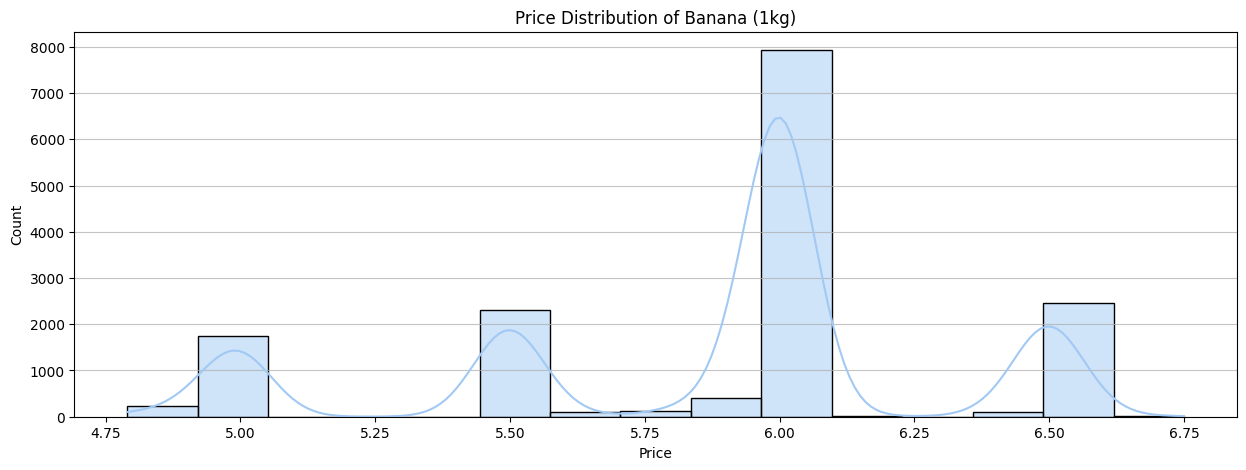

In [102]:
plt.figure(figsize = (15, 5))
sns.histplot(df_banana['price'], bins = binwidth, kde = True)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution of Banana (1kg)')
plt.grid(axis = 'y', alpha = 0.75)
plt.show()

Conclusion: Left skewed, use median for aggregation.

### **Papaya**

In [103]:
#calculate binwidth using Sturges' Rule
binwidth = 1 + 3.22 * np.log10(len(df_papaya))
binwidth = int(math.ceil(binwidth))

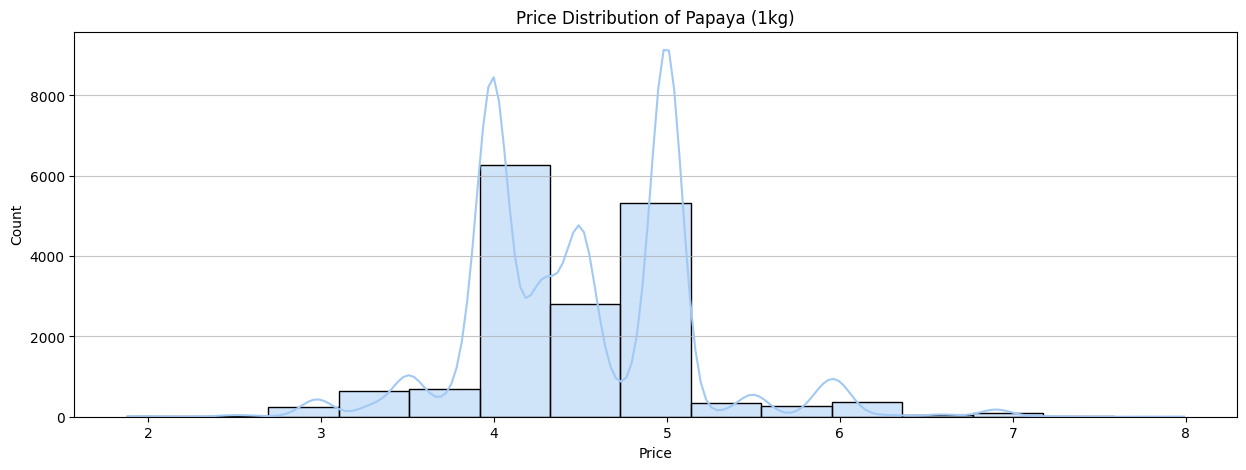

In [104]:
plt.figure(figsize = (15, 5))
sns.histplot(df_papaya['price'], bins = binwidth, kde = True)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution of Papaya (1kg)')
plt.grid(axis = 'y', alpha = 0.75)
plt.show()

### **Rice**

In [105]:
#calculate binwidth using Sturges' Rule
binwidth = 1 + 3.22 * np.log10(len(df_rice))
binwidth = int(math.ceil(binwidth))

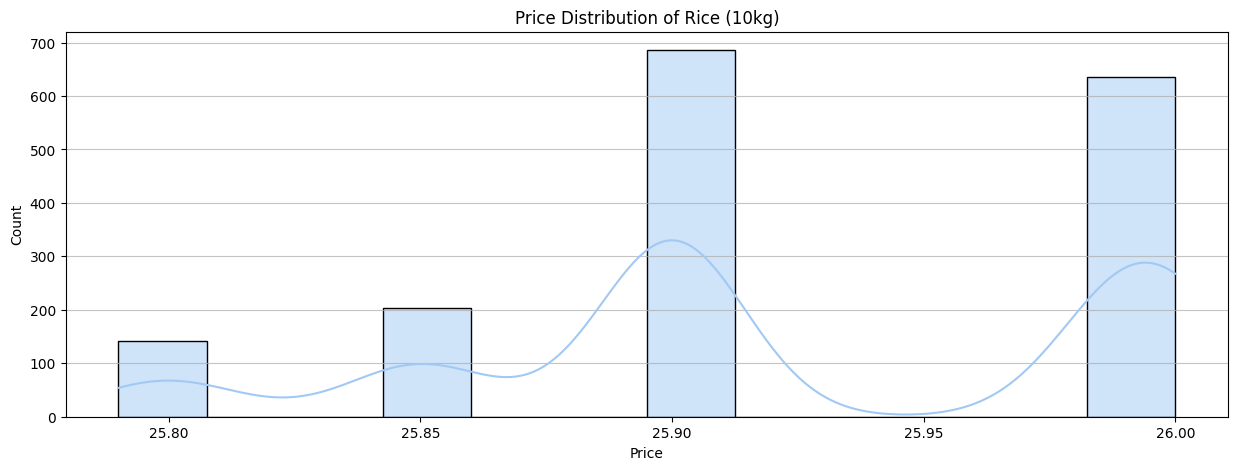

In [106]:
plt.figure(figsize = (15, 5))
sns.histplot(df_rice['price'], bins = binwidth, kde = True)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution of Rice (10kg)')
plt.grid(axis = 'y', alpha = 0.75)
plt.show()

Conclusion: Left skewed, use median for aggregation.

### **Bread**

In [107]:
#calculate binwidth using Sturges' Rule
binwidth = 1 + 3.22 * np.log10(len(df_bread))
binwidth = int(math.ceil(binwidth))

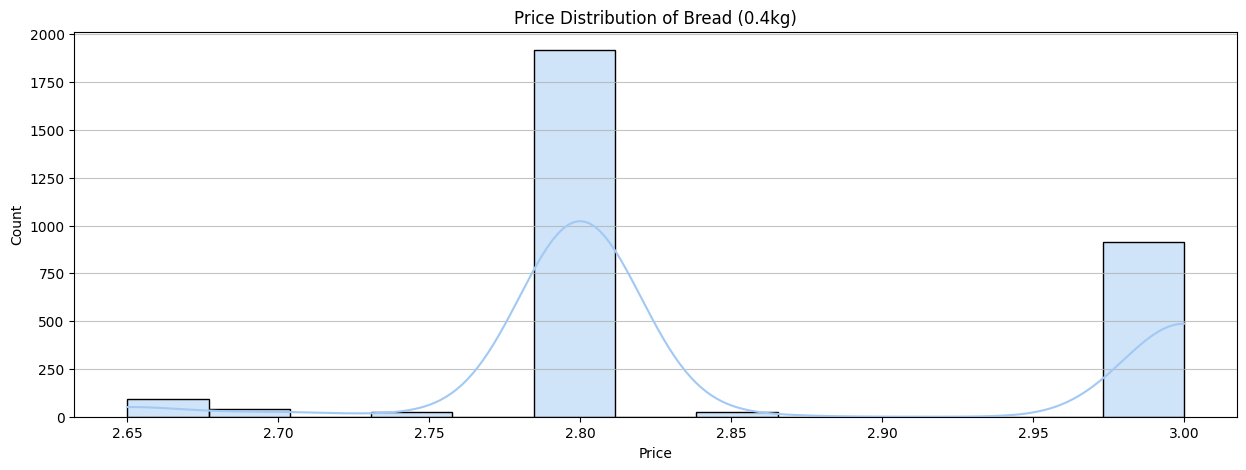

In [108]:
plt.figure(figsize = (15, 5))
sns.histplot(df_bread['price'], bins = binwidth, kde = True)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution of Bread (0.4kg)')
plt.grid(axis = 'y', alpha = 0.75)
plt.show()

Conclusion: Bimodal, use median for aggregation.

### **Fish**

In [109]:
#calculate binwidth using Sturges' Rule
binwidth = 1 + 3.22 * np.log10(len(df_fish))
binwidth = int(math.ceil(binwidth))

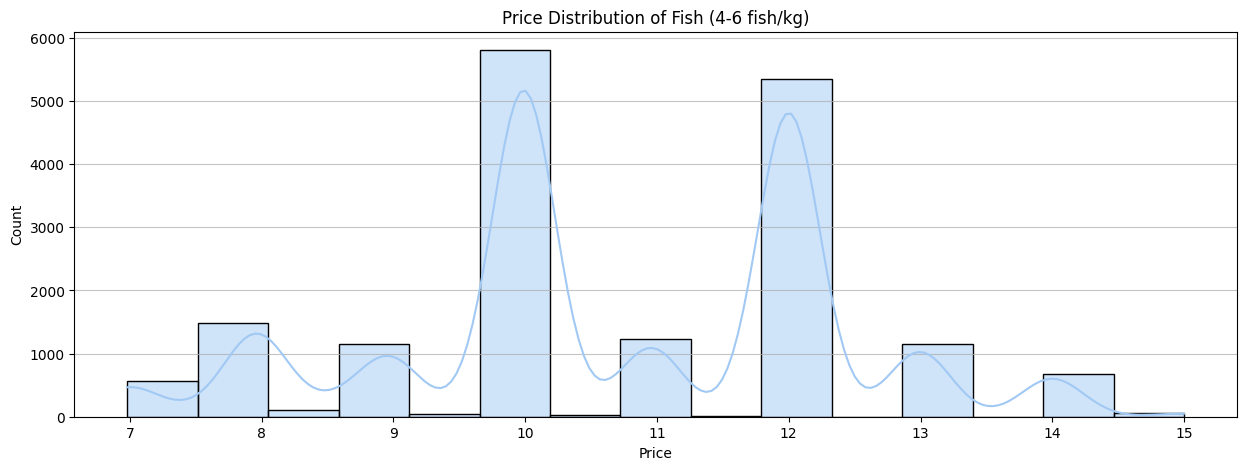

In [110]:
plt.figure(figsize = (15, 5))
sns.histplot(df_fish['price'], bins = binwidth, kde = True)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution of Fish (4-6 fish/kg)')
plt.grid(axis = 'y', alpha = 0.75)
plt.show()

Conclusion: Bimodal, use median for aggregation.

### **Chicken**

In [111]:
#calculate binwidth using Sturges' Rule
binwidth = 1 + 3.22 * np.log10(len(df_chicken))
binwidth = int(math.ceil(binwidth))

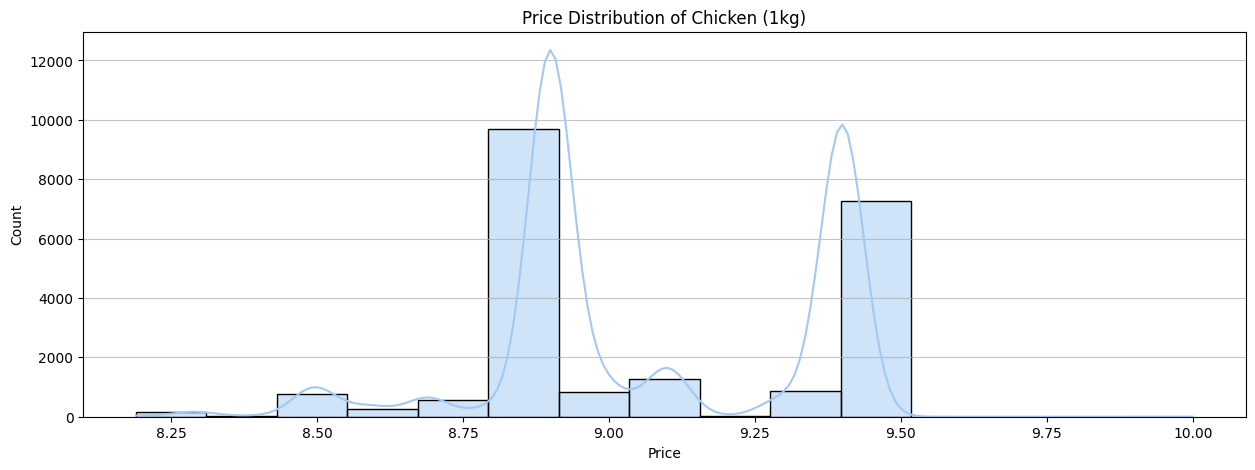

In [112]:
plt.figure(figsize = (15, 5))
sns.histplot(df_chicken['price'], bins = binwidth, kde = True)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution of Chicken (1kg)')
plt.grid(axis = 'y', alpha = 0.75)
plt.show()

Conclusion: Bimodal, use median for aggregation.

### **Carrot**

In [113]:
#calculate binwidth using Sturges' Rule
binwidth = 1 + 3.22 * np.log10(len(df_carrot))
binwidth = int(math.ceil(binwidth))

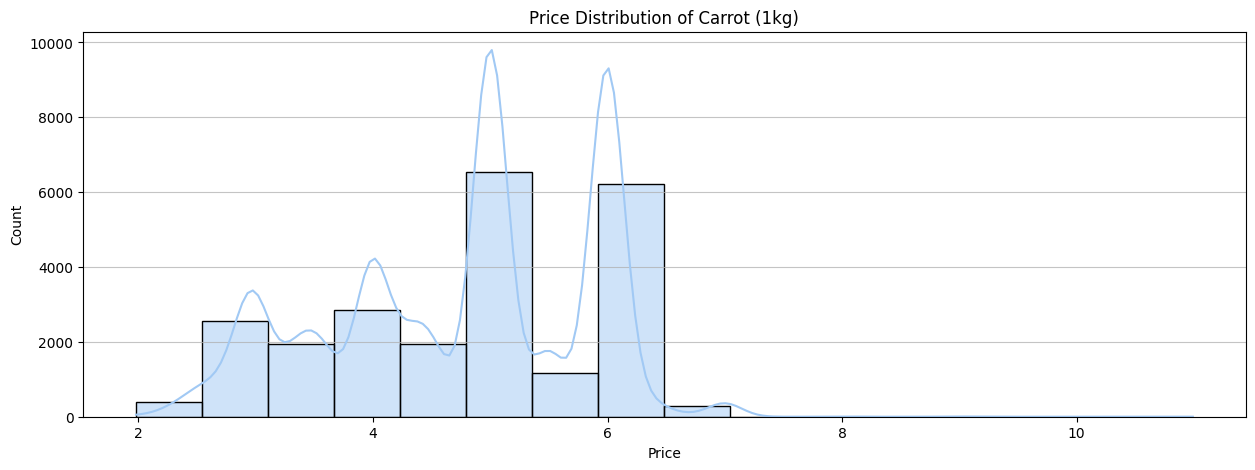

In [114]:
plt.figure(figsize = (15, 5))
sns.histplot(df_carrot['price'], bins = binwidth, kde = True)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution of Carrot (1kg)')
plt.grid(axis = 'y', alpha = 0.75)
plt.show()

Conclusion: Right skewed, use median for aggregation.

### **Tomato**

In [115]:
#calculate binwidth using Sturges' Rule
binwidth = 1 + 3.22 * np.log10(len(df_tomato))
binwidth = int(math.ceil(binwidth))

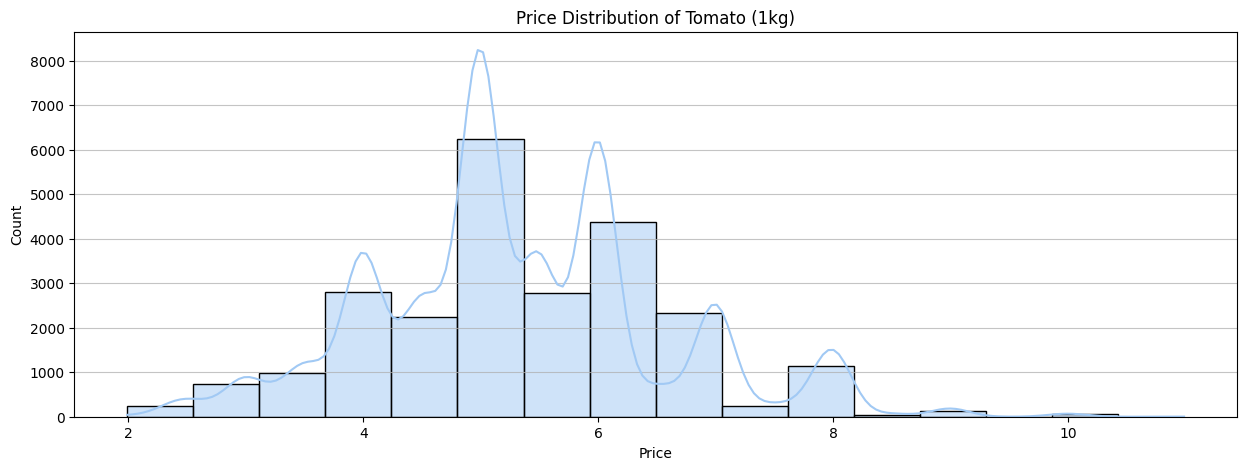

In [116]:
plt.figure(figsize = (15, 5))
sns.histplot(df_tomato['price'], bins = binwidth, kde = True)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution of Tomato (1kg)')
plt.grid(axis = 'y', alpha = 0.75)
plt.show()

Conclusion: Right skewed, use median for aggregation.

### **Cauliflower**

In [117]:
#calculate binwidth using Sturges' Rule
binwidth = 1 + 3.22 * np.log10(len(df_cauliflower))
binwidth = int(math.ceil(binwidth))

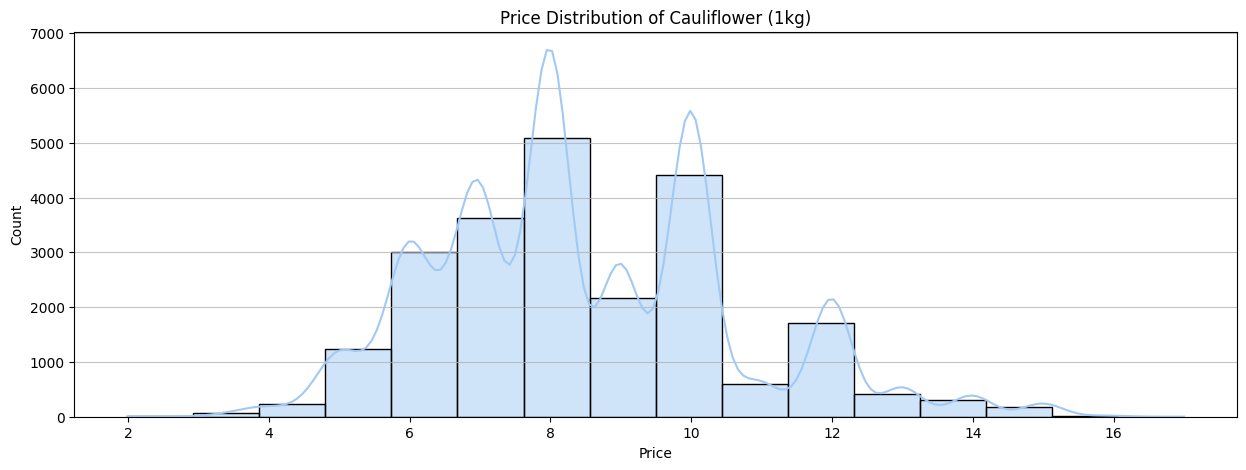

In [118]:
plt.figure(figsize = (15, 5))
sns.histplot(df_cauliflower['price'], bins = binwidth, kde = True)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution of Cauliflower (1kg)')
plt.grid(axis = 'y', alpha = 0.75)
plt.show()

Conclusion: Right skewed, use mean for aggregation.

### **Milk**

In [119]:
#calculate binwidth using Sturges' Rule
binwidth = 1 + 3.22 * np.log10(len(df_milk))
binwidth = int(math.ceil(binwidth))

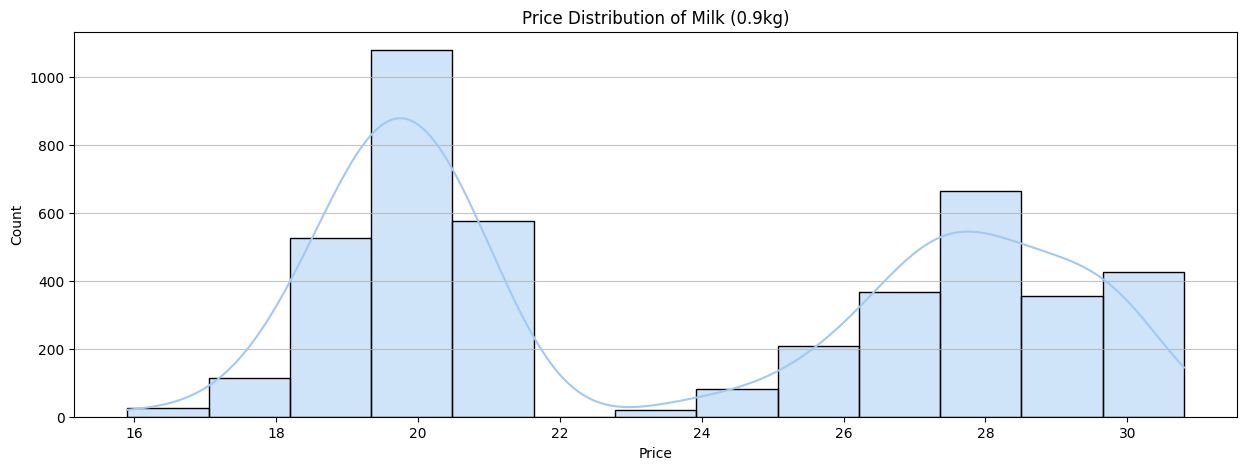

In [120]:
plt.figure(figsize = (15, 5))
sns.histplot(df_milk['price'], bins = binwidth, kde = True)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution of Milk (0.9kg)')
plt.grid(axis = 'y', alpha = 0.75)
plt.show()

Conclusion: Bimodal, use median for aggregation.

## **Data Aggregation**

In [121]:
banana_ag = df_banana.groupby('district')['price'].median().reset_index()
banana_ag.columns = ['district', 'banana_price']
banana_ag

,district,banana_price
0,Barat Daya,6.0
1,Seberang Perai Selatan,5.5
2,Seberang Perai Tengah,6.0
3,Seberang Perai Utara,6.0
4,Timur Laut,6.0


In [122]:
papaya_ag = df_papaya.groupby('district')['price'].median().reset_index()
papaya_ag.columns = ['district', 'papaya_price']
papaya_ag

,district,papaya_price
0,Barat Daya,4.50
1,Seberang Perai Selatan,4.00
2,Seberang Perai Tengah,4.29
3,Seberang Perai Utara,4.00
4,Timur Laut,4.89


In [123]:
rice_ag = df_rice.groupby('district')['price'].median().reset_index()
rice_ag.columns = ['district', 'rice_price']
rice_ag

,district,rice_price
0,Barat Daya,25.90
1,Seberang Perai Selatan,25.90
2,Seberang Perai Tengah,25.99
3,Seberang Perai Utara,25.90
4,Timur Laut,25.90


In [124]:
bread_ag = df_bread.groupby('district')['price'].median().reset_index()
bread_ag.columns = ['district', 'bread_price']
bread_ag

,district,bread_price
0,Barat Daya,2.8
1,Seberang Perai Selatan,2.8
2,Seberang Perai Tengah,2.8
3,Seberang Perai Utara,2.8
4,Timur Laut,2.8


In [125]:
fish_ag = df_fish.groupby('district')['price'].median().reset_index()
fish_ag.columns = ['district', 'fish_price']
fish_ag

,district,fish_price
0,Barat Daya,10.00
1,Seberang Perai Selatan,12.00
2,Seberang Perai Tengah,9.99
3,Seberang Perai Utara,12.00
4,Timur Laut,10.00


In [126]:
chicken_ag = df_chicken.groupby('district')['price'].median().reset_index()
chicken_ag.columns = ['district', 'chicken_price']
chicken_ag

,district,chicken_price
0,Barat Daya,8.90
1,Seberang Perai Selatan,8.90
2,Seberang Perai Tengah,8.90
3,Seberang Perai Utara,8.90
4,Timur Laut,8.99


In [127]:
carrot_ag = df_carrot.groupby('district')['price'].median().reset_index()
carrot_ag.columns = ['district', 'carrot_price']
carrot_ag

,district,carrot_price
0,Barat Daya,5.00
1,Seberang Perai Selatan,4.50
2,Seberang Perai Tengah,4.49
3,Seberang Perai Utara,5.00
4,Timur Laut,5.00


In [128]:
tomato_ag = df_tomato.groupby('district')['price'].median().reset_index()
tomato_ag.columns = ['district', 'tomato_price']
tomato_ag

,district,tomato_price
0,Barat Daya,5.49
1,Seberang Perai Selatan,5.00
2,Seberang Perai Tengah,5.00
3,Seberang Perai Utara,5.00
4,Timur Laut,5.49


In [129]:
cauliflower_ag = df_cauliflower.groupby('district')['price'].median().reset_index()
cauliflower_ag.columns = ['district', 'cauliflower_price']
cauliflower_ag

,district,cauliflower_price
0,Barat Daya,8.00
1,Seberang Perai Selatan,7.99
2,Seberang Perai Tengah,7.90
3,Seberang Perai Utara,8.00
4,Timur Laut,8.90


In [130]:
milk_ag = df_milk.groupby('district')['price'].median().reset_index()
milk_ag.columns = ['district', 'milk_price']
milk_ag

,district,milk_price
0,Barat Daya,20.90
1,Seberang Perai Selatan,20.90
2,Seberang Perai Tengah,20.90
3,Seberang Perai Utara,20.99
4,Timur Laut,20.90


In [131]:
df_price_merged = banana_ag.merge(papaya_ag, on = 'district', how = 'outer').merge(rice_ag, on = 'district', how = 'outer')\
    .merge(bread_ag, on = 'district', how = 'outer').merge(fish_ag, on = 'district', how = 'outer')\
    .merge(chicken_ag, on = 'district', how = 'outer').merge(carrot_ag, on = 'district', how = 'outer')\
    .merge(tomato_ag, on = 'district', how = 'outer').merge(cauliflower_ag, on = 'district', how = 'outer')\
    .merge(milk_ag, on = 'district', how = 'outer')

df_price_merged

,district,banana_price,papaya_price,rice_price,bread_price,fish_price,chicken_price,carrot_price,tomato_price,cauliflower_price,milk_price
0,Barat Daya,6.0,4.50,25.90,2.8,10.00,8.90,5.00,5.49,8.00,20.90
1,Seberang Perai Selatan,5.5,4.00,25.90,2.8,12.00,8.90,4.50,5.00,7.99,20.90
2,Seberang Perai Tengah,6.0,4.29,25.99,2.8,9.99,8.90,4.49,5.00,7.90,20.90
3,Seberang Perai Utara,6.0,4.00,25.90,2.8,12.00,8.90,5.00,5.00,8.00,20.99
4,Timur Laut,6.0,4.89,25.90,2.8,10.00,8.99,5.00,5.49,8.90,20.90


# **Kids Dataset**

In [132]:
#import dataset
df_kids = pd.read_excel("Dataset/DATA_ANAK_2022.xlsx")

In [133]:
#show top 5 lines of df_kids
df_kids.head()

,cm_rec_id,UMUR (BULAN),BANGSA,AGAMA,JANTINA,PENDAPATAN KELUARGA,GAJI BAPA,GAJI IBU,GAJI PENJAGA,STATUS PEMAKANAN,...,DAERAH,PARLIMEN,DUN,JENIS TASKA,TASKA_LOKASI,BERAT (KG),TINGGI (CM),BMI,WEIGHT FOR AGE,HEIGHT FOR AGE
0,113823,45,Orang Sungai,Islam,LELAKI,Tiada Maklumat,"RM 1,000 - RM 3,999","RM 1,000 - RM 3,999",MAKLUMAT SALAH,Error/Tiada Data,...,Kinabatangan,KINABATANGAN,KINABATANGAN - KUAMUT,TASKA Di Rumah,BANDAR,NaN,NaN,NaN,NaN,NaN
1,118278,44,Orang Sungai,Islam,PEREMPUAN,Tiada Maklumat,"RM 1,000 - RM 3,999","RM 1,000 - RM 3,999",MAKLUMAT SALAH,Error/Tiada Data,...,Kinabatangan,KINABATANGAN,KINABATANGAN - KUAMUT,TASKA Di Rumah,BANDAR,NaN,NaN,NaN,NaN,NaN
2,121176,55,Cina,Buddha,PEREMPUAN,Tiada Maklumat,MAKLUMAT SALAH,MAKLUMAT SALAH,MAKLUMAT SALAH,Error/Tiada Data,...,Muar,MUAR,MUAR - MAHARANI,TASKA Institusi,BANDAR,NaN,NaN,NaN,NaN,NaN
3,142655,39,Melayu,Islam,PEREMPUAN,Tiada Maklumat,"RM 1,000 - RM 3,999","RM 1,000 - RM 3,999","RM 1,000 - RM 3,999",Malpemakanan,...,Bangsar Pudu,CHERAS,TIADA,TASKA Institusi,BANDAR,17.9,110.0,Berat badan normal,Further assessment,PEMANTAUAN LANJUT
4,145555,60,Melayu,Islam,LELAKI,Tiada Maklumat,"RM 1,000 - RM 3,999","RM 1,000 - RM 3,999",MAKLUMAT SALAH,Error/Tiada Data,...,Kinabatangan,KINABATANGAN,KINABATANGAN - KUAMUT,TASKA Di Rumah,BANDAR,NaN,NaN,NaN,NaN,NaN


In [134]:
#print total number of lines in df_kids
print("Total Lines: ", len(df_kids))

Total Lines:  60737


In [135]:
#show data types of attributes in df_kids
df_kids.dtypes

cm_rec_id                int64
UMUR (BULAN)             int64
BANGSA                  object
AGAMA                   object
JANTINA                 object
PENDAPATAN KELUARGA     object
GAJI BAPA               object
GAJI IBU                object
GAJI PENJAGA            object
STATUS PEMAKANAN        object
NEGERI                  object
DAERAH                  object
PARLIMEN                object
DUN                     object
JENIS TASKA             object
TASKA_LOKASI            object
BERAT (KG)             float64
TINGGI (CM)            float64
BMI                     object
WEIGHT FOR AGE          object
HEIGHT FOR AGE          object
dtype: object

In [136]:
df_kids.describe()

,cm_rec_id,UMUR (BULAN),BERAT (KG),TINGGI (CM)
count,60737.000000,60737.000000,16136.000000,16136.000000
mean,312124.693630,37.598680,12.274287,84.674263
std,39216.391552,12.777455,28.166080,18.398173
min,3060.000000,1.000000,0.000000,0.000000
25%,289858.000000,30.000000,9.800000,78.000000
50%,321655.000000,39.000000,11.700000,87.000000
75%,344177.000000,48.000000,13.600000,94.000000
max,360489.000000,60.000000,3405.000000,976.000000


In [137]:
#convert attributes with object data type from object data type to string data type
df_kids['BANGSA']              = df_kids['BANGSA'].astype('str')
df_kids['AGAMA']               = df_kids['AGAMA'].astype('str')
df_kids['JANTINA']             = df_kids['JANTINA'].astype('str')
df_kids['PENDAPATAN KELUARGA'] = df_kids['PENDAPATAN KELUARGA'].astype('str')
df_kids['GAJI BAPA']           = df_kids['GAJI BAPA'].astype('str')
df_kids['GAJI IBU']            = df_kids['GAJI IBU'].astype('str')
df_kids['GAJI PENJAGA']        = df_kids['GAJI PENJAGA'].astype('str')
df_kids['STATUS PEMAKANAN']    = df_kids['STATUS PEMAKANAN'].astype('str')
df_kids['NEGERI']              = df_kids['NEGERI'].astype('str')
df_kids['DAERAH']              = df_kids['DAERAH'].astype('str')
df_kids['PARLIMEN']            = df_kids['PARLIMEN'].astype('str')
df_kids['DUN']                 = df_kids['DUN'].astype('str')
df_kids['JENIS TASKA']         = df_kids['JENIS TASKA'].astype('str')
df_kids['TASKA_LOKASI']        = df_kids['TASKA_LOKASI'].astype('str')
df_kids['BMI']                 = df_kids['BMI'].astype('str')
df_kids['WEIGHT FOR AGE']      = df_kids['WEIGHT FOR AGE'].astype('str')
df_kids['HEIGHT FOR AGE']       = df_kids['HEIGHT FOR AGE'].astype('str')

In [138]:
#show number of values for each attribute in df_kids
for column in df_kids:
  unique_vals = np.unique(df_kids[column])
  nr_values = len(unique_vals)
  if nr_values < 37:
    print('The number of values for feature {} :{} -- {}'.format(column, nr_values, unique_vals))
  else:
    print('The number of values for feature {} :{}'.format(column, nr_values))

The number of values for feature cm_rec_id :60737
The number of values for feature UMUR (BULAN) :60
The number of values for feature BANGSA :37
The number of values for feature AGAMA :7 -- ['Buddha' 'Hindu' 'Islam' 'Kristian' 'Lain-lain' 'Sikh' 'nan']
The number of values for feature JANTINA :2 -- ['LELAKI' 'PEREMPUAN']
The number of values for feature PENDAPATAN KELUARGA :6 -- ['Kumpulan B40 (Pendapatan isi rumah di bawah RM 4,360.00)'
 'Kumpulan M40 (Pendapatan isi rumah RM 4,360.00 - RM 9,619.00)'
 'Kumpulan T20 (Pendapatan isi rumah RM 9,620.00 ke atas)'
 'Miskin (Pendapatan isi rumah kurang RM 980.00)' 'Tiada Maklumat' 'nan']
The number of values for feature GAJI BAPA :8 -- ['Kurang RM 1,000' 'MAKLUMAT SALAH' 'RM 1,000 - RM 3,999'
 'RM 10,000 dan ke atas' 'RM 4,000 - RM 6,999' 'RM 7,000 - RM 9,999'
 'TIADA MAKLUMAT GAJI' 'Tiada Pendapatan']
The number of values for feature GAJI IBU :8 -- ['Kurang RM 1,000' 'MAKLUMAT SALAH' 'RM 1,000 - RM 3,999'
 'RM 10,000 dan ke atas' 'RM 4,000 -

## **Data Cleaning**

In [139]:
#keep rows with state='Pulau Pinang' in df_kids
df_kids_PP=df_kids[df_kids["NEGERI"] == 'Pulau Pinang']

In [140]:
df_kids_PP = df_kids_PP.drop(columns=['cm_rec_id', 'NEGERI', 'DUN', 'WEIGHT FOR AGE', 'HEIGHT FOR AGE'])

In [141]:
#show top 5 lines of df_kids_PP
df_kids_PP.head()

,UMUR (BULAN),BANGSA,AGAMA,JANTINA,PENDAPATAN KELUARGA,GAJI BAPA,GAJI IBU,GAJI PENJAGA,STATUS PEMAKANAN,DAERAH,PARLIMEN,JENIS TASKA,TASKA_LOKASI,BERAT (KG),TINGGI (CM),BMI
67,59,Melayu,Islam,PEREMPUAN,Tiada Maklumat,"RM 1,000 - RM 3,999","RM 1,000 - RM 3,999",MAKLUMAT SALAH,Error/Tiada Data,Seberang Perai Tengah,BUKIT MERTAJAM,TASKA Institusi,BANDAR,NaN,NaN,nan
68,60,Melayu,Islam,LELAKI,"Kumpulan M40 (Pendapatan isi rumah RM 4,360.00...","RM 4,000 - RM 6,999","RM 4,000 - RM 6,999","RM 4,000 - RM 6,999",Malpemakanan,Seberang Perai Tengah,PERMATANG PAUH,TASKA Institusi,BANDAR,12.0,85.0,Risiko berlebihan berat badan
77,59,Cina,Buddha,PEREMPUAN,Tiada Maklumat,"RM 4,000 - RM 6,999","RM 1,000 - RM 3,999","RM 1,000 - RM 3,999",Error/Tiada Data,Daerah Barat Daya,BAYAN BARU,TASKA Institusi,BANDAR,NaN,NaN,nan
86,60,Melayu,Islam,PEREMPUAN,"Kumpulan M40 (Pendapatan isi rumah RM 4,360.00...","RM 1,000 - RM 3,999","RM 1,000 - RM 3,999",MAKLUMAT SALAH,Error/Tiada Data,Daerah Timur Laut,TANJONG,TASKA Di Tempat Kerja (Sektor Awam),BANDAR,NaN,NaN,nan
295,54,Melayu,Islam,LELAKI,Tiada Maklumat,"RM 10,000 dan ke atas","RM 4,000 - RM 6,999","RM 4,000 - RM 6,999",Malpemakanan,Seberang Perai Tengah,PERMATANG PAUH,TASKA Institusi,BANDAR,10.0,73.2,Berlebihan berat badan


In [142]:
#print total number of lines in df_kids_PP
print("Total Lines: ", len(df_kids_PP))

Total Lines:  2539


In [143]:
#check null rows in df_kids_PP
print(df_kids_PP.isnull().sum())

UMUR (BULAN)              0
BANGSA                    0
AGAMA                     0
JANTINA                   0
PENDAPATAN KELUARGA       0
GAJI BAPA                 0
GAJI IBU                  0
GAJI PENJAGA              0
STATUS PEMAKANAN          0
DAERAH                    0
PARLIMEN                  0
JENIS TASKA               0
TASKA_LOKASI              0
BERAT (KG)             1842
TINGGI (CM)            1842
BMI                       0
dtype: int64


In [144]:
# Drop rows with any null values
df_kids_PP = df_kids_PP.dropna()

# Print the number of lines after dropping null rows
print("Total Lines after dropping nulls: ", len(df_kids_PP))

Total Lines after dropping nulls:  697


## **Exploratory Data Analysis**

### **Distribution between Weight and Height**

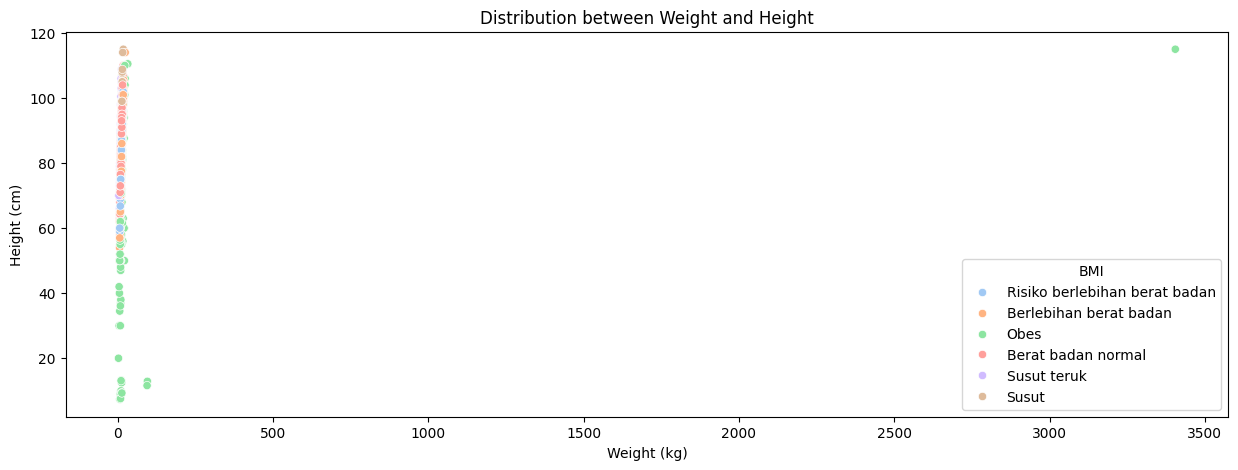

In [145]:
plt.figure(figsize = (15, 5))
sns.scatterplot(x = 'BERAT (KG)', y = 'TINGGI (CM)', data = df_kids_PP, hue = 'BMI')
plt.title('Distribution between Weight and Height')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
plt.show()

### **Removing Outliers**

#### **Remove Outliers for Weight**

In [146]:
#calculate Q1, Q3, and IQR
Q1 = df_kids_PP['BERAT (KG)'].quantile(0.25)
Q3 = df_kids_PP['BERAT (KG)'].quantile(0.75)
IQR = Q3 - Q1

#define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#filter out outliers
df_kids_PP_no_outliers = df_kids_PP[(df_kids_PP['BERAT (KG)'] >= lower_bound) & (df_kids_PP['BERAT (KG)'] <= upper_bound)]

print("Total Lines after removing outliers: ", len(df_kids_PP_no_outliers))

Total Lines after removing outliers:  684


In [147]:
df_kids_PP = df_kids_PP_no_outliers

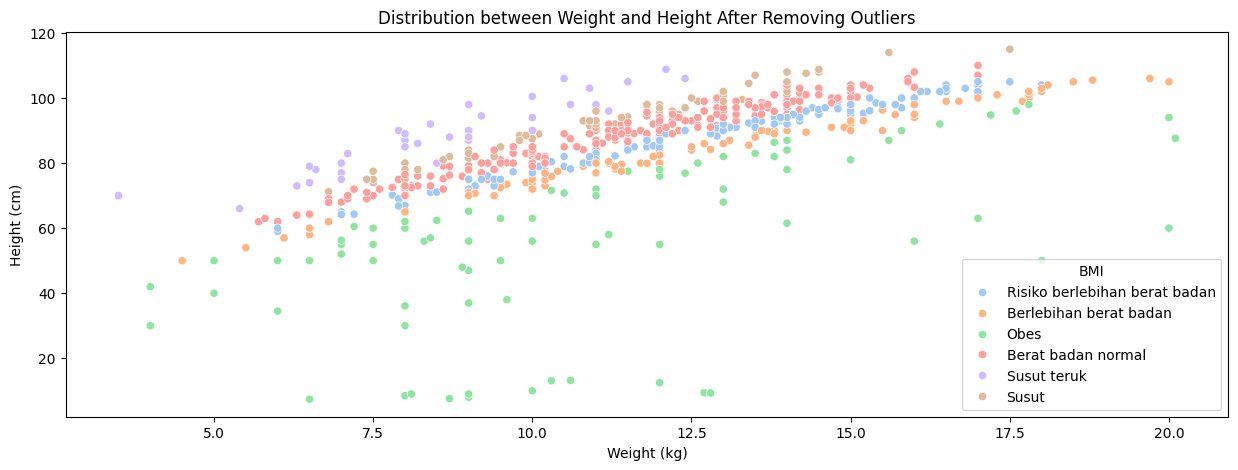

In [148]:
plt.figure(figsize = (15, 5))
sns.scatterplot(x = 'BERAT (KG)', y = 'TINGGI (CM)', data = df_kids_PP, hue = 'BMI')
plt.title('Distribution between Weight and Height After Removing Outliers')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
plt.show()

In [149]:
export_path = "Dataset/kids.csv" 
df_kids_PP.to_csv(export_path, index=False)

### **Distribution of Kids' Residential Area**

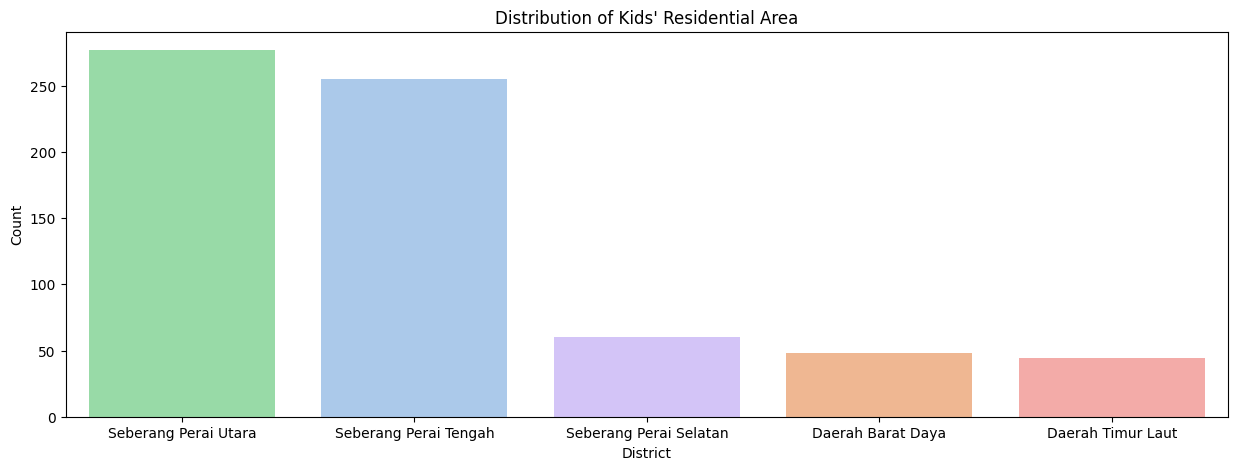

In [150]:
plt.figure(figsize = (15, 5))
sns.countplot(df_kids_PP, x = 'DAERAH', hue = 'DAERAH', order = df_kids_PP['DAERAH'].value_counts().index)
title = "Distribution of Kids' Residential Area"
plt.title(title)
plt.xlabel('District')
plt.ylabel('Count')
plt.show()

### **Distribution of BMI**

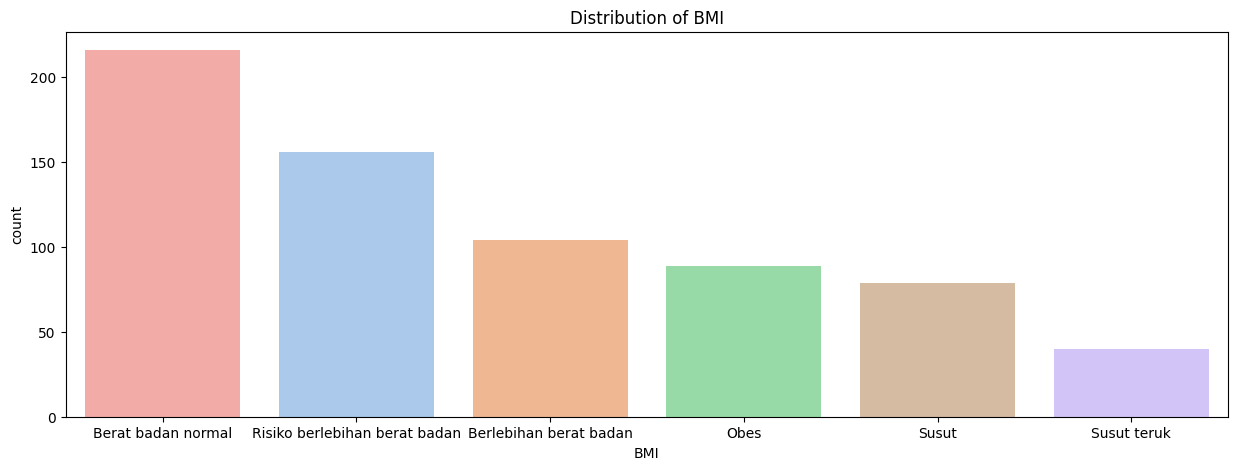

In [151]:
plt.figure(figsize = (15, 5))
sns.countplot(df_kids_PP, x = 'BMI', hue = 'BMI', order = df_kids_PP['BMI'].value_counts().index)
title = "Distribution of BMI"
plt.title(title)
plt.show()

### **BMI by Races**

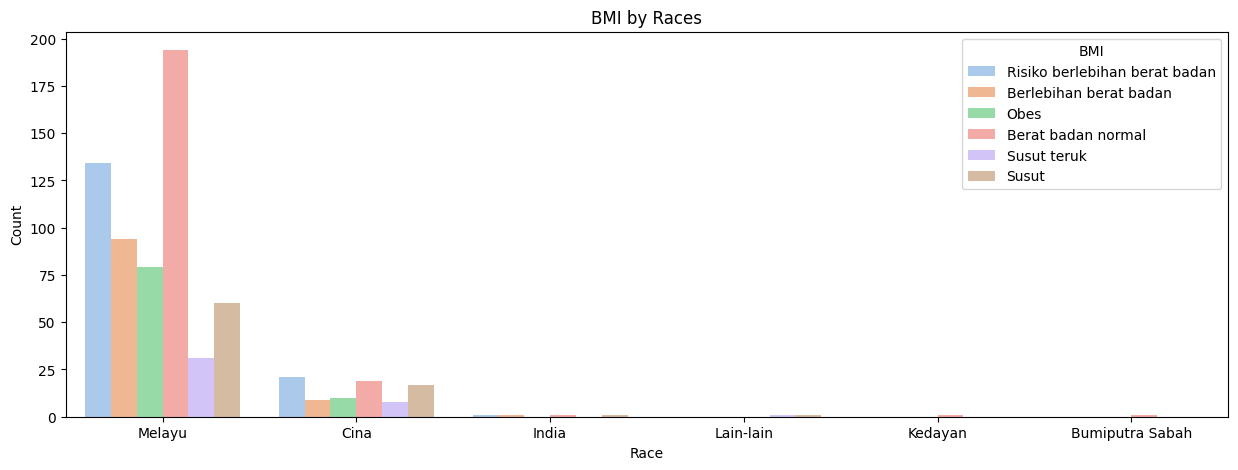

In [152]:
plt.figure(figsize=(15, 5))
sns.countplot(df_kids_PP, x = 'BANGSA', hue = 'BMI', order = df_kids_PP['BANGSA'].value_counts().index)
title = "BMI by Races"
plt.title(title)
plt.xlabel('Race')
plt.ylabel('Count')
plt.show()

### **BMI by Gender**

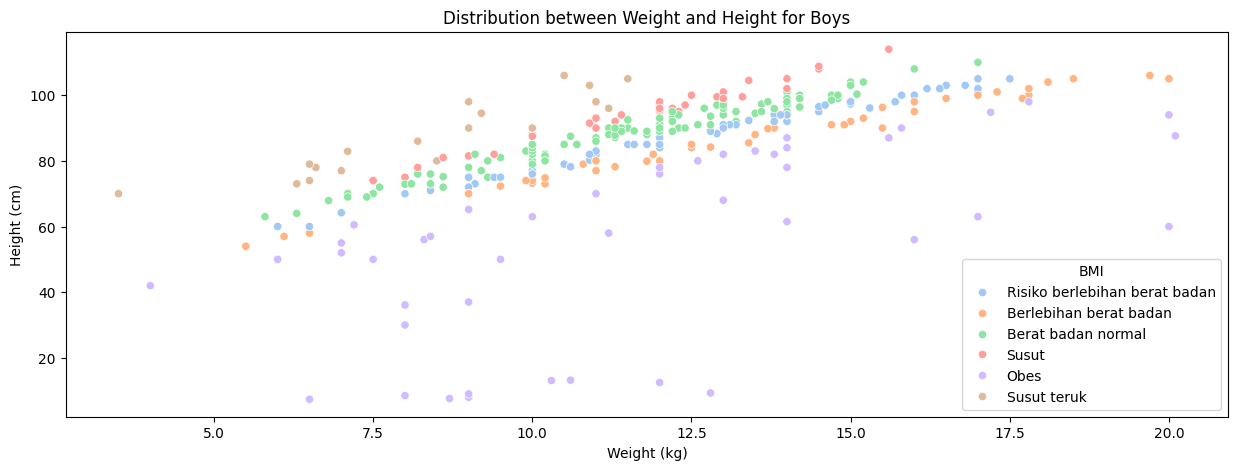

In [153]:
plt.figure(figsize = (15, 5))
p = sns.scatterplot(x = 'BERAT (KG)', y = 'TINGGI (CM)', data = df_kids_PP[df_kids_PP['JANTINA'] == 'LELAKI'], hue = 'BMI')
plt.title('Distribution between Weight and Height for Boys')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
sns.move_legend(p, "lower right")
plt.show()

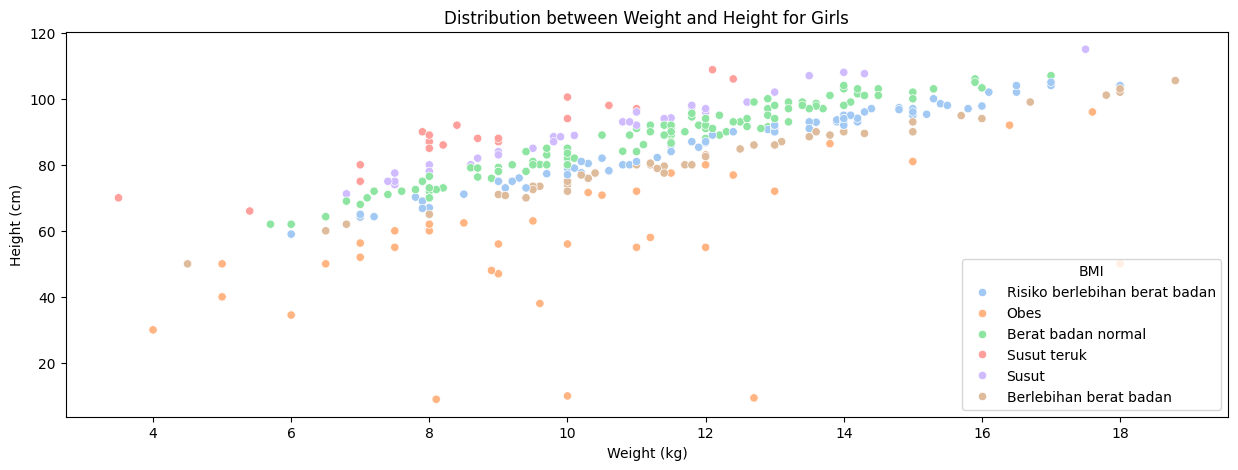

In [154]:
plt.figure(figsize = (15, 5))
p = sns.scatterplot(x = 'BERAT (KG)', y = 'TINGGI (CM)', data=df_kids_PP[df_kids_PP['JANTINA'] == 'PEREMPUAN'], hue = 'BMI')
plt.title('Distribution between Weight and Height for Girls')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
sns.move_legend(p, "lower right")
plt.show()

### **BMI by Household Income**

In [155]:
df_kids_PP['PENDAPATAN KELUARGA'] = df_kids_PP['PENDAPATAN KELUARGA'].map({'Tiada Maklumat': 'Tiada Maklumat',
                                                                           'Kumpulan M40 (Pendapatan isi rumah RM 4,360.00 - RM 9,619.00)': 'M40',
                                                                           'Kumpulan B40 (Pendapatan isi rumah di bawah RM 4,360.00)': 'B40',
                                                                           'Kumpulan T20 (Pendapatan isi rumah RM 9,620.00 ke atas)': 'T20',
                                                                           'Miskin (Pendapatan isi rumah kurang RM 980.00)': 'Miskin'})

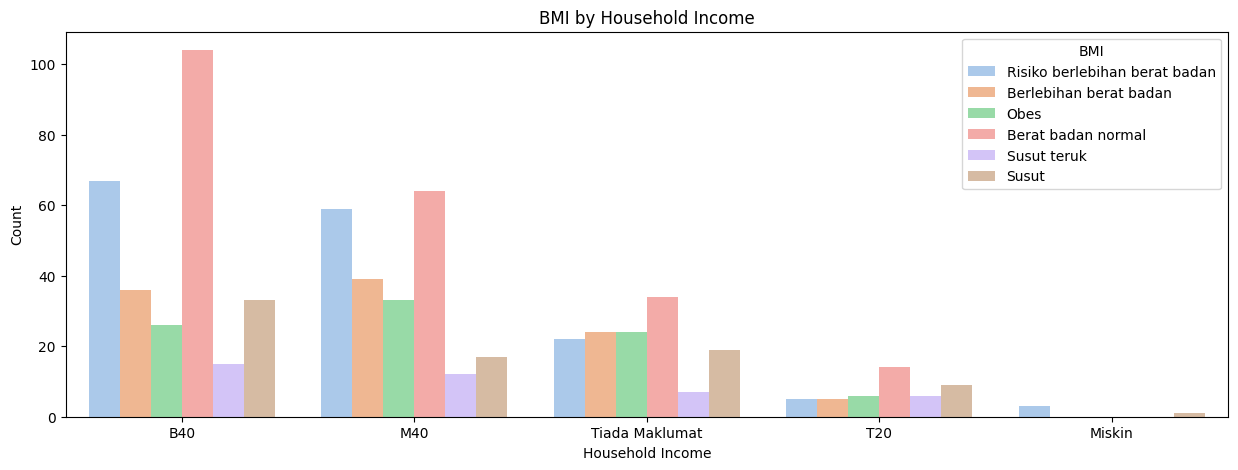

In [156]:
plt.figure(figsize = (15, 5))
sns.countplot(df_kids_PP, x = 'PENDAPATAN KELUARGA', hue = 'BMI', order = df_kids_PP['PENDAPATAN KELUARGA'].value_counts().index)
title = "BMI by Household Income"
plt.title(title)
plt.xlabel('Household Income')
plt.ylabel('Count')
plt.show()

### **BMI by District**

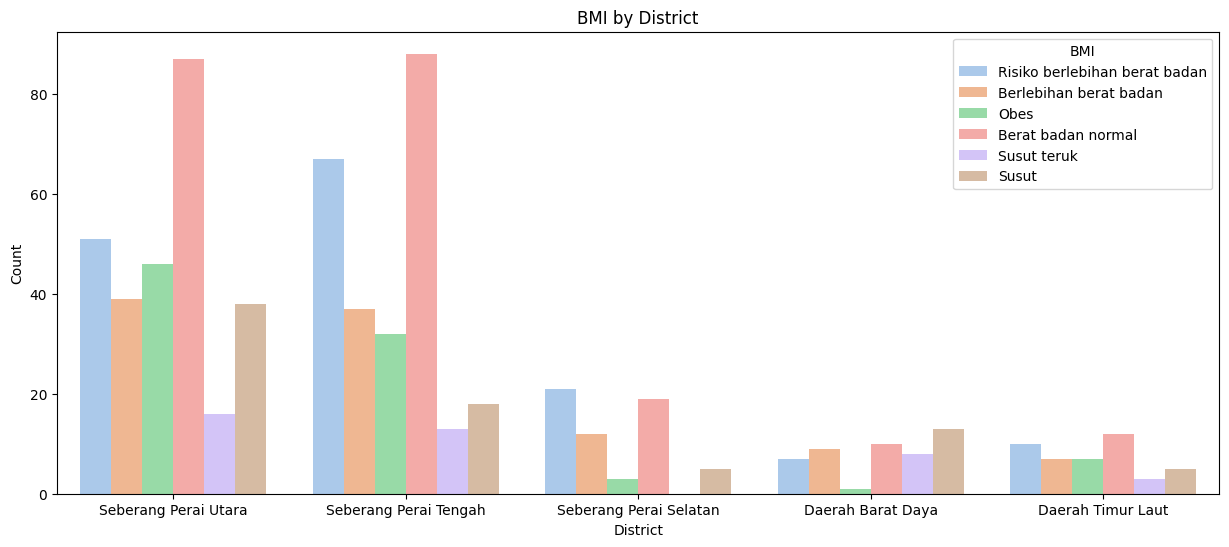

In [157]:
plt.figure(figsize = (15, 6))
sns.countplot(df_kids_PP, x = 'DAERAH', hue = 'BMI', order = df_kids_PP['DAERAH'].value_counts().index)
title = "BMI by District"
plt.title(title)
plt.xlabel('District')
plt.ylabel('Count')
plt.show()

### **Distribution between Age (Months) and BMI**

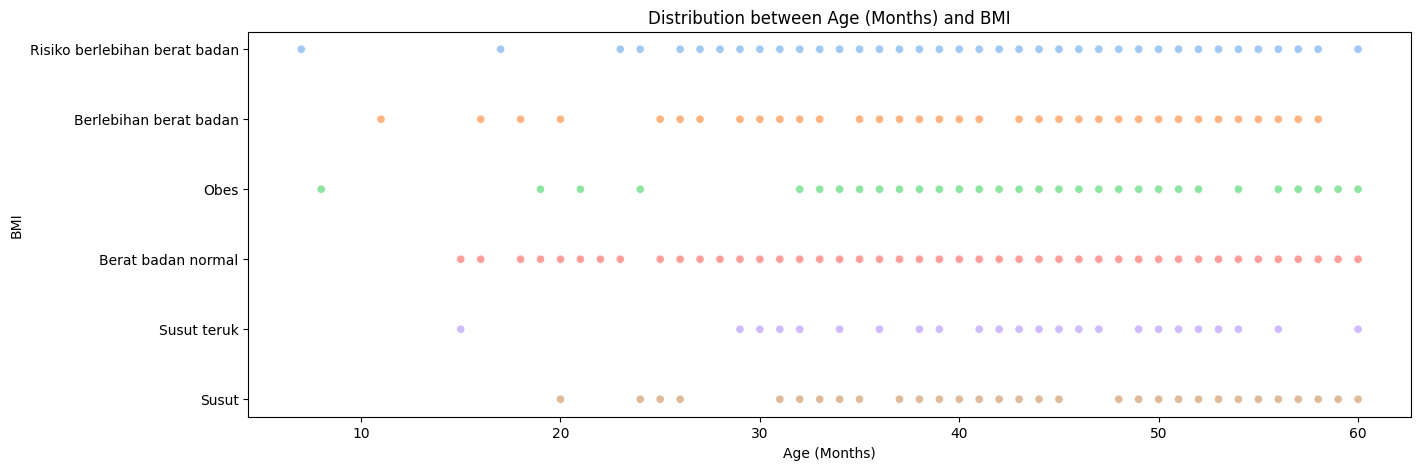

In [158]:
plt.figure(figsize = (15, 5))
sns.scatterplot(x = 'UMUR (BULAN)', y = 'BMI', data = df_kids_PP, hue = 'BMI', legend = False)
plt.title('Distribution between Age (Months) and BMI')
plt.xlabel('Age (Months)')
plt.ylabel('BMI')
plt.show()

### **Relationship between Age (Months), Gender, and BMI**

C:\Users\hp\AppData\Local\Temp\ipykernel_5804\321983806.py:9: UserWarning: Mismatched number of handles and labels: len(handles) = 6 len(labels) = 2
  p.legend(handles = handles, labels = new_labels, title = "Gender")


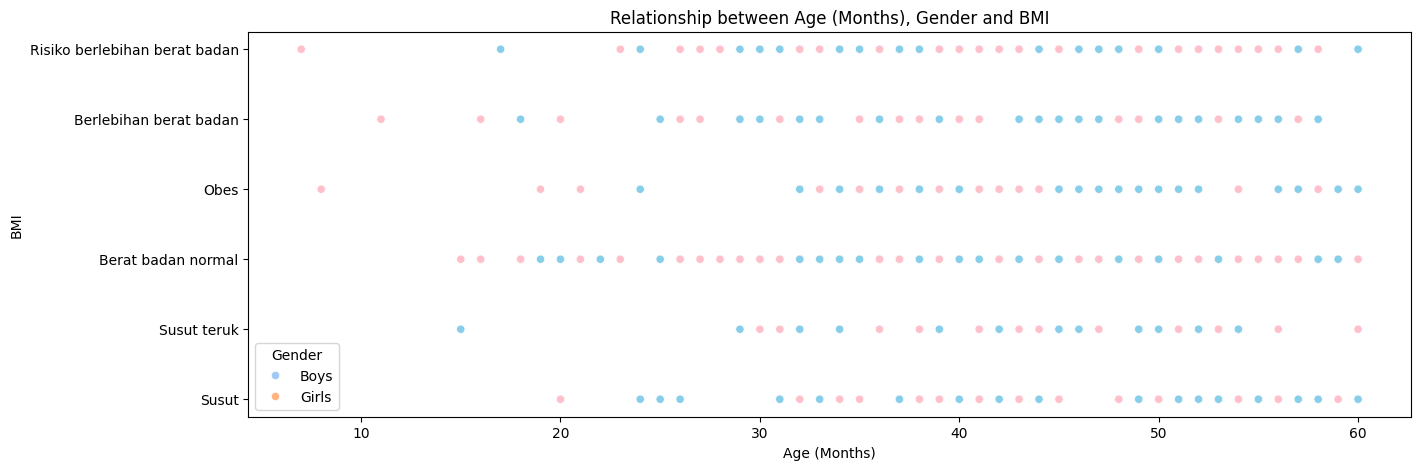

In [159]:
handles, previous_labels = p.get_legend_handles_labels()
new_labels = ['Boys', 'Girls']

plt.figure(figsize = (15, 5))
p = sns.scatterplot(x = 'UMUR (BULAN)', y = 'BMI', data = df_kids_PP, hue = 'JANTINA', palette = ['skyblue', 'pink'])
plt.title('Relationship between Age (Months), Gender and BMI')
plt.xlabel('Age (Months)')
plt.ylabel('BMI')
p.legend(handles = handles, labels = new_labels, title = "Gender")
plt.show()

### **Count of each Type of Taska in each Parliament**

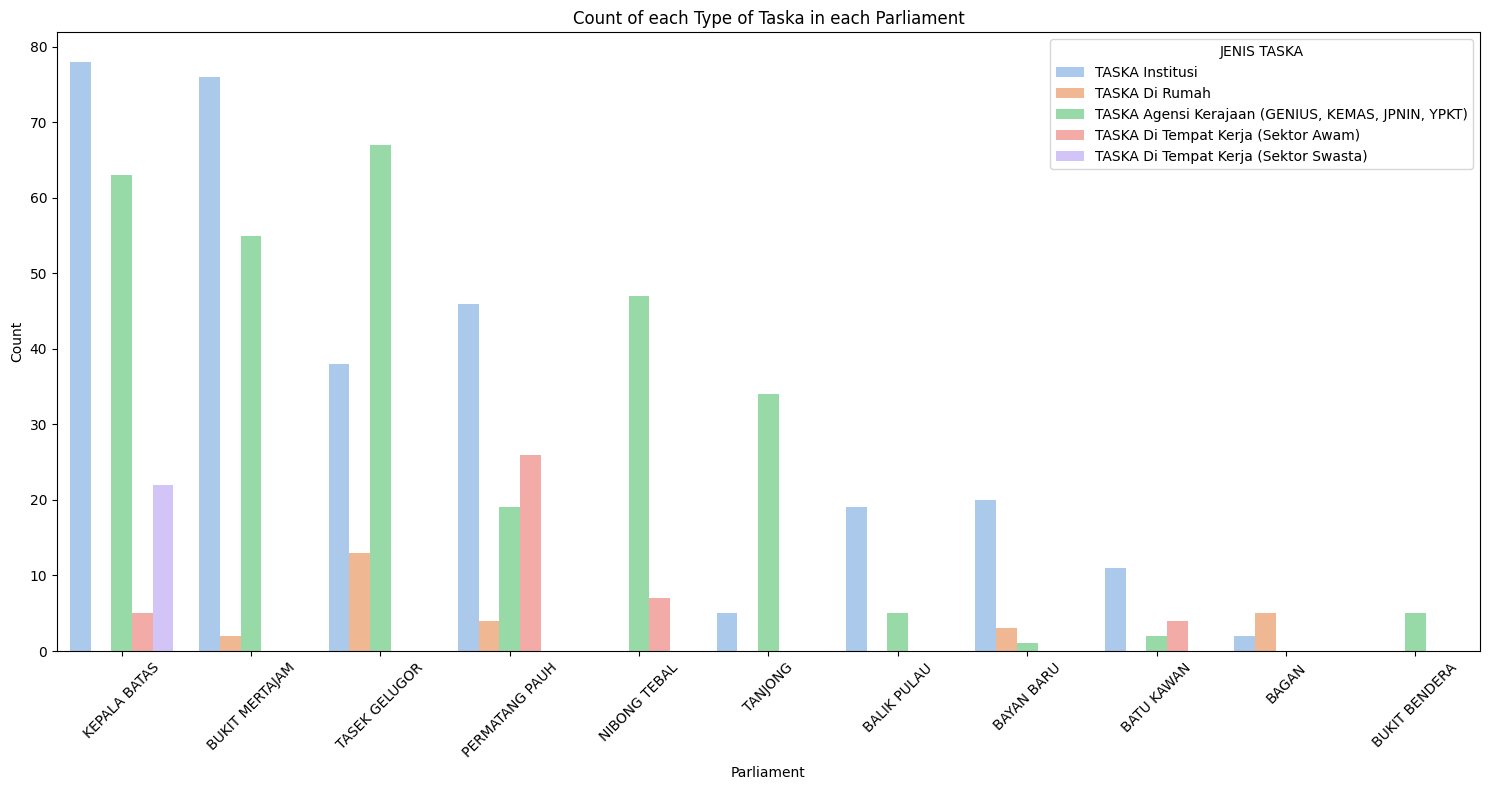

In [160]:
plt.figure(figsize=(15, 8))
sns.countplot(x='PARLIMEN', hue='JENIS TASKA', data=df_kids_PP, order=df_kids_PP['PARLIMEN'].value_counts().index)
plt.title('Count of each Type of Taska in each Parliament')
plt.xlabel('Parliament')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


### **Heatmap of Parliment and BMI**

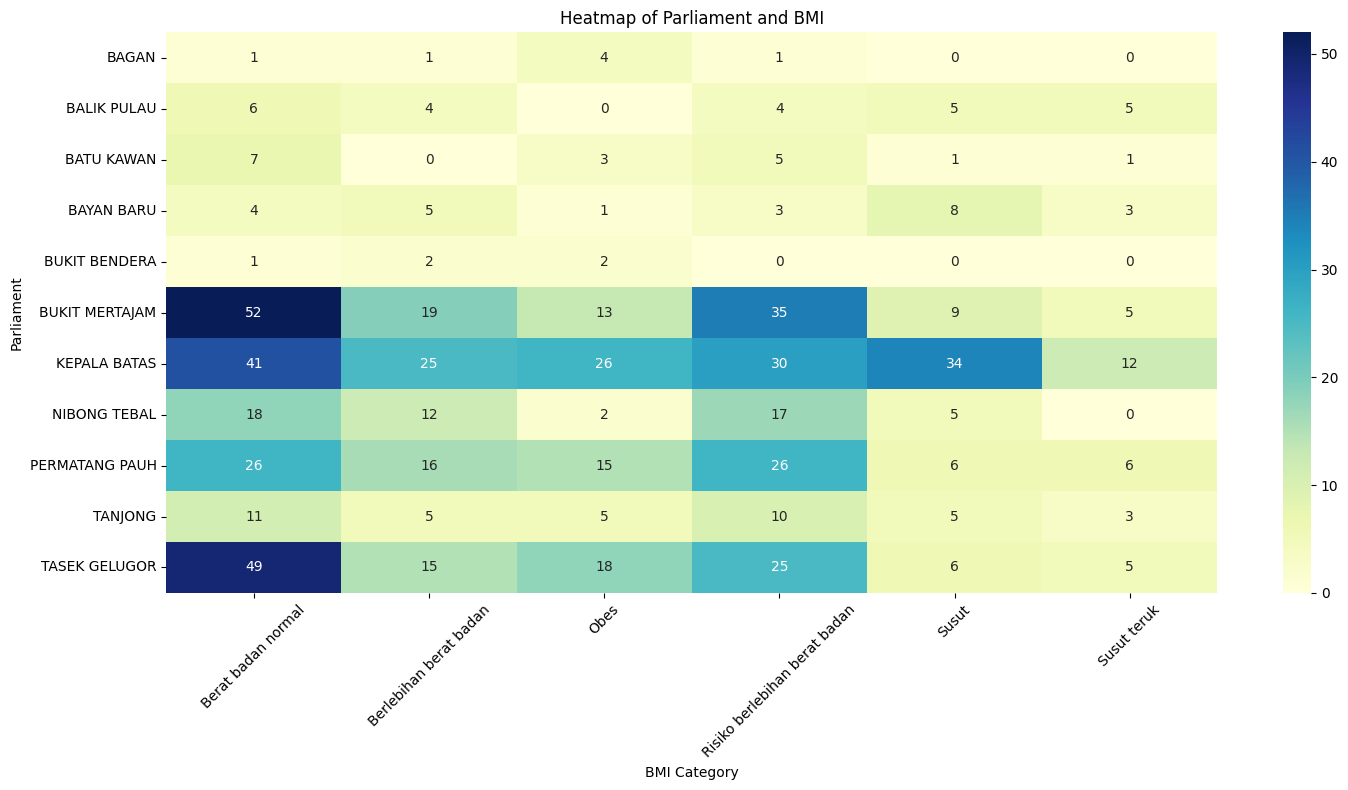

In [161]:
# Create a cross-tabulation of 'PARLIMEN' and 'BMI'
parliment_bmi_counts = pd.crosstab(df_kids_PP['PARLIMEN'], df_kids_PP['BMI'])

# Plotting the relationship using a heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(parliment_bmi_counts, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Heatmap of Parliament and BMI")
plt.xlabel("BMI Category")
plt.ylabel("Parliament")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Dataset Export**

In [162]:
df_kids_PP = df_kids_PP.drop(['PARLIMEN', 'TINGGI (CM)', 'BERAT (KG)'], axis=1)

In [163]:
export_path = "Dataset/df_kids_PP.csv" 
df_kids_PP.to_csv(export_path, index=False)

# **Final Dataframes Merging**

In [164]:
df_price_merged = df_price_merged.rename(columns={"district": "DAERAH"})
df_price_merged = df_price_merged.replace({'DAERAH': {'Barat Daya': 'Daerah Barat Daya', 'Timur Laut': 'Daerah Timur Laut'}})
df_price_merged

,DAERAH,banana_price,papaya_price,rice_price,bread_price,fish_price,chicken_price,carrot_price,tomato_price,cauliflower_price,milk_price
0,Daerah Barat Daya,6.0,4.50,25.90,2.8,10.00,8.90,5.00,5.49,8.00,20.90
1,Seberang Perai Selatan,5.5,4.00,25.90,2.8,12.00,8.90,4.50,5.00,7.99,20.90
2,Seberang Perai Tengah,6.0,4.29,25.99,2.8,9.99,8.90,4.49,5.00,7.90,20.90
3,Seberang Perai Utara,6.0,4.00,25.90,2.8,12.00,8.90,5.00,5.00,8.00,20.99
4,Daerah Timur Laut,6.0,4.89,25.90,2.8,10.00,8.99,5.00,5.49,8.90,20.90


In [165]:
df_merged = df_kids_PP.merge(df_price_merged, on='DAERAH', how='left')
df_merged.head()

,UMUR (BULAN),BANGSA,AGAMA,JANTINA,PENDAPATAN KELUARGA,GAJI BAPA,GAJI IBU,GAJI PENJAGA,STATUS PEMAKANAN,DAERAH,...,banana_price,papaya_price,rice_price,bread_price,fish_price,chicken_price,carrot_price,tomato_price,cauliflower_price,milk_price
0,60,Melayu,Islam,LELAKI,M40,"RM 4,000 - RM 6,999","RM 4,000 - RM 6,999","RM 4,000 - RM 6,999",Malpemakanan,Seberang Perai Tengah,...,6.0,4.29,25.99,2.8,9.99,8.9,4.49,5.00,7.9,20.9
1,54,Melayu,Islam,LELAKI,Tiada Maklumat,"RM 10,000 dan ke atas","RM 4,000 - RM 6,999","RM 4,000 - RM 6,999",Malpemakanan,Seberang Perai Tengah,...,6.0,4.29,25.99,2.8,9.99,8.9,4.49,5.00,7.9,20.9
2,53,Melayu,Islam,PEREMPUAN,B40,"RM 1,000 - RM 3,999","RM 1,000 - RM 3,999","RM 1,000 - RM 3,999",Malpemakanan,Seberang Perai Tengah,...,6.0,4.29,25.99,2.8,9.99,8.9,4.49,5.00,7.9,20.9
3,52,Melayu,Islam,PEREMPUAN,B40,"RM 1,000 - RM 3,999","RM 1,000 - RM 3,999","RM 1,000 - RM 3,999",Malpemakanan,Seberang Perai Tengah,...,6.0,4.29,25.99,2.8,9.99,8.9,4.49,5.00,7.9,20.9
4,58,Melayu,Islam,LELAKI,B40,"RM 1,000 - RM 3,999",TIADA MAKLUMAT GAJI,"RM 1,000 - RM 3,999",Malpemakanan,Daerah Barat Daya,...,6.0,4.50,25.90,2.8,10.00,8.9,5.00,5.49,8.0,20.9


In [166]:
df_merged.dtypes

UMUR (BULAN)             int64
BANGSA                  object
AGAMA                   object
JANTINA                 object
PENDAPATAN KELUARGA     object
GAJI BAPA               object
GAJI IBU                object
GAJI PENJAGA            object
STATUS PEMAKANAN        object
DAERAH                  object
JENIS TASKA             object
TASKA_LOKASI            object
BMI                     object
banana_price           float64
papaya_price           float64
rice_price             float64
bread_price            float64
fish_price             float64
chicken_price          float64
carrot_price           float64
tomato_price           float64
cauliflower_price      float64
milk_price             float64
dtype: object

In [167]:
export_path = "Dataset/kids_price.csv"
df_merged.to_csv(export_path, index=False)